##  Setup and Automatic Dataset Loading

This section initialises the notebook environment and automatically loads the processed merged dataset from the repository. The project root is detected dynamically using `pathlib`, ensuring the notebook works correctly regardless of where the repository is cloned or executed. This keeps the workflow collaborative and GitHub-friendly.

**Key actions in this step:**
- Import core analytical and visualisation libraries  
- Configure pandas and plotting styles  
- Automatically locate the project root (by detecting the `data/` directory)  
- Build a reliable relative path to the processed dataset  
- Load the dataset into a pandas DataFrame  
- Confirm successful loading by printing the file path, dataset shape, and preview

Once the dataset is loaded, the next steps will focus on examining structure, missing values, and ensuring the data is ready for deeper EDA.


In [3]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_merged_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\data\processed\final_merged_dataset.csv
Shape: (338, 8)


,CPI ANNUAL RATE 00: ALL ITEMS 2015=100,Date,YearMonth,Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,Exchange_USD,"Unemployment rate (aged 16 and over, seasonally adjusted): %",RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,Bank Rate
0,1.7,1997-06-01,1997-06,1.0,1.6446,7.3,9.3,5.9375
1,2.0,1997-07-01,1997-07,0.6,1.6702,7.1,14.0,5.9375
2,2.0,1997-08-01,1997-08,0.9,1.6034,6.8,14.1,5.9375
3,1.8,1997-09-01,1997-09,0.8,1.6015,6.7,11.2,5.9375
4,1.9,1997-10-01,1997-10,1.0,1.6329,6.6,8.5,5.9375


##  Data Structure and Initial Sanity Checks

In this step, we inspect the structure and integrity of the merged dataset before performing deeper EDA.

### Objectives:
- Display all column names to understand the dataset schema  
- Inspect data types and non-null counts  
- Check for missing values and their percentages  
- Identify any duplicate rows  
- Validate the time index:
  - Convert `Date` column to datetime if required  
  - Check minimum and maximum date  
  - Verify dataset is sorted chronologically  

These sanity checks ensure that the dataset is clean, consistent, and ready for time-series analysis in later steps.


In [4]:
# Step 2: Data Structure and Initial Sanity Checks

# 1. Column names and count
print("Total number of columns:", len(df.columns))
print("\nColumn names:")
for col in df.columns:
    print("-", col)

print("\n" + "="*90)

# 2. Data types and non-null summary
print("DataFrame Info:")
df.info()
print("\n" + "="*90)

# 3. Missing values summary
missing_summary = (
    df.isna()
      .sum()
      .to_frame(name="missing_count")
)
missing_summary["missing_pct"] = (df.isna().mean() * 100).round(2)

print("Missing Values Summary:")
display(missing_summary.sort_values("missing_count", ascending=False))

print("\n" + "="*90)

# 4. Duplicate rows count
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows found: {duplicate_rows}")

print("\n" + "="*90)

# 5. Date handling and validation
if "Date" in df.columns:
    # Convert to datetime if required
    if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
    # Sort by date
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Date range reporting
    print("Date column processed successfully.")
    print("Minimum Date:", df["Date"].min())
    print("Maximum Date:", df["Date"].max())

    # NaT values count (if coercion occurred)
    invalid_date_count = df["Date"].isna().sum()
    print("Invalid/NaT dates:", invalid_date_count)
else:
    print("⚠️ No 'Date' column found in dataset.")

print("\n" + "="*90)

# 6. Preview first few rows
df.head()


Total number of columns: 8

Column names:
- CPI ANNUAL RATE 00: ALL ITEMS 2015=100
- Date
- YearMonth
- Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA
- Exchange_USD
- Unemployment rate (aged 16 and over, seasonally adjusted): %
- RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil
- Bank Rate

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 8 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   CPI ANNUAL RATE 00: ALL ITEMS 2015=100                                338 non-null    float64
 1   Date                                                                  338 non-null    object 
 2   YearMonth                                                             338 non-null    object 
 3   Gross Value Added - Monthly (3 month on 3 month gr

,missing_count,missing_pct
CPI ANNUAL RATE 00: ALL ITEMS 2015=100,0,0.0
Date,0,0.0
YearMonth,0,0.0
Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,0,0.0
Exchange_USD,0,0.0
"Unemployment rate (aged 16 and over, seasonally adjusted): %",0,0.0
RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,0,0.0
Bank Rate,0,0.0



Duplicate rows found: 0

Date column processed successfully.
Minimum Date: 1997-06-01 00:00:00
Maximum Date: 2025-07-01 00:00:00
Invalid/NaT dates: 0



,CPI ANNUAL RATE 00: ALL ITEMS 2015=100,Date,YearMonth,Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA,Exchange_USD,"Unemployment rate (aged 16 and over, seasonally adjusted): %",RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil,Bank Rate
0,1.7,1997-06-01,1997-06,1.0,1.6446,7.3,9.3,5.9375
1,2.0,1997-07-01,1997-07,0.6,1.6702,7.1,14.0,5.9375
2,2.0,1997-08-01,1997-08,0.9,1.6034,6.8,14.1,5.9375
3,1.8,1997-09-01,1997-09,0.8,1.6015,6.7,11.2,5.9375
4,1.9,1997-10-01,1997-10,1.0,1.6329,6.6,8.5,5.9375


##  Core Time-Series Plots

This section visualises the main macroeconomic time series used in the model:

1. CPI year-on-year (headline inflation) over time  
2. Petrol and oil price inflation vs CPI  
3. Bank Rate (monetary policy stance) over time  
4. GBP/USD exchange rate over time  
5. Unemployment rate vs CPI (Phillips curve intuition)  
6. Gross Value Added (GVA) growth vs CPI (activity–inflation link)

The aim is to visually inspect trends, cycles, and obvious shocks (e.g. global financial crisis, Brexit, COVID-19, recent inflation spike).


## Step 4 — Key Time-Series Plots with Brexit and COVID Regimes

This section focuses on a set of “VIP” graphs for the main variables used in the model.  
The objective is to visualise how UK inflation and its key drivers evolved across major economic regimes:

- **Brexit period**
- **Pre-COVID period**
- **COVID period**
- **Post-COVID period**

For clarity, the following approximate regime boundaries are used:

- **Brexit referendum:** June 2016  
- **COVID period:** March 2020 – June 2021  
- **Post-COVID period:** July 2021 onwards  

These regimes are highlighted directly on the charts to support the later discussion of structural breaks and regime-dependent model performance.

Variables plotted:
- CPI annual rate (headline inflation)
- Petrol and oil price inflation (RPI component)
- Bank Rate (monetary policy)
- GBP/USD exchange rate
- Unemployment rate
- Gross Value Added (GVA) growth


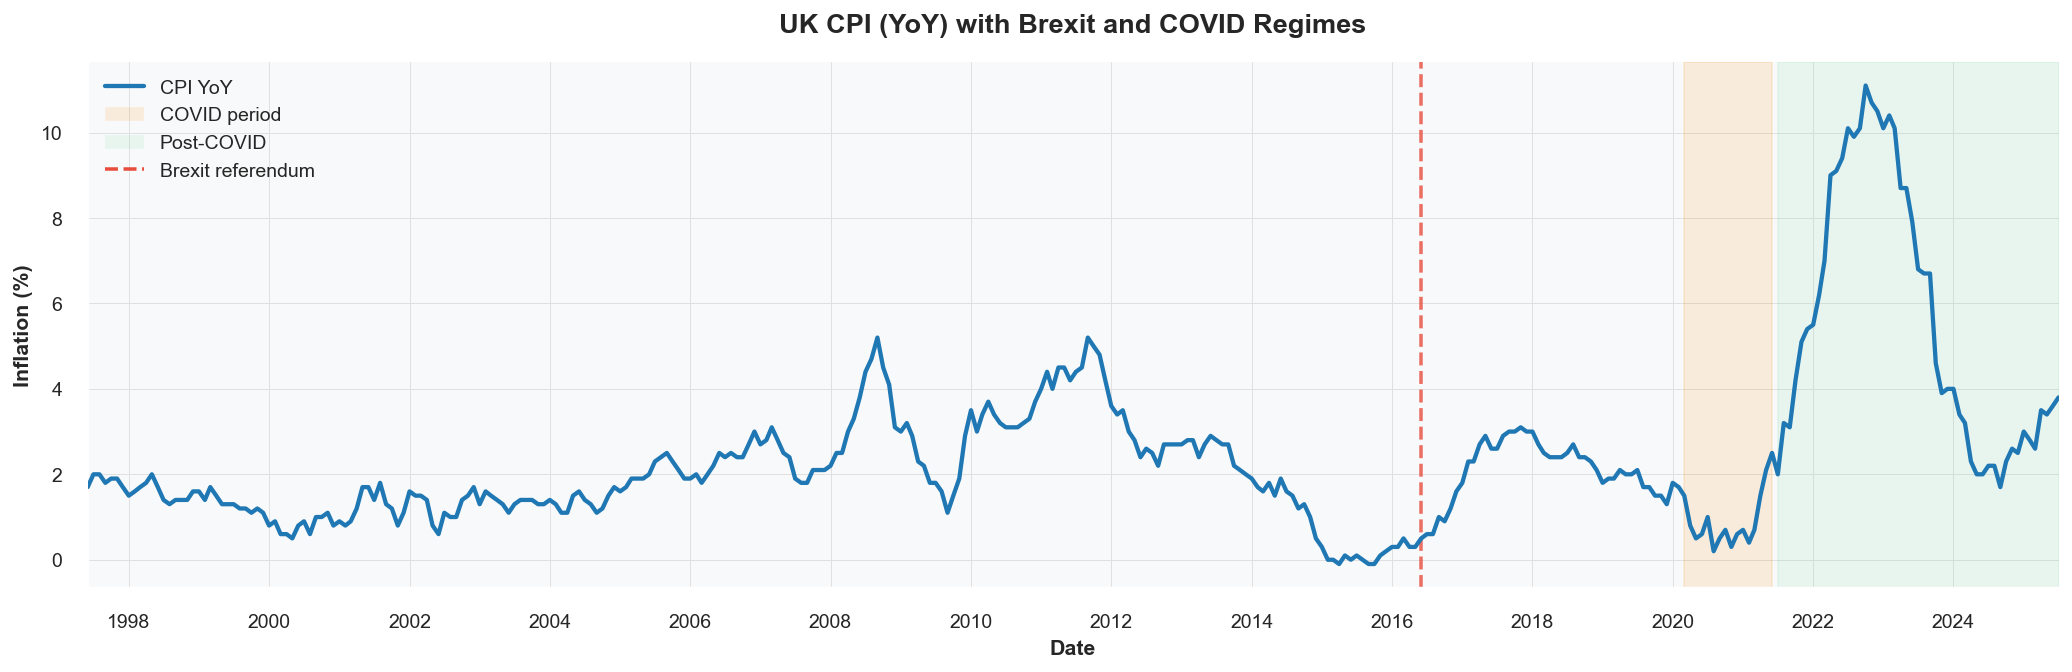

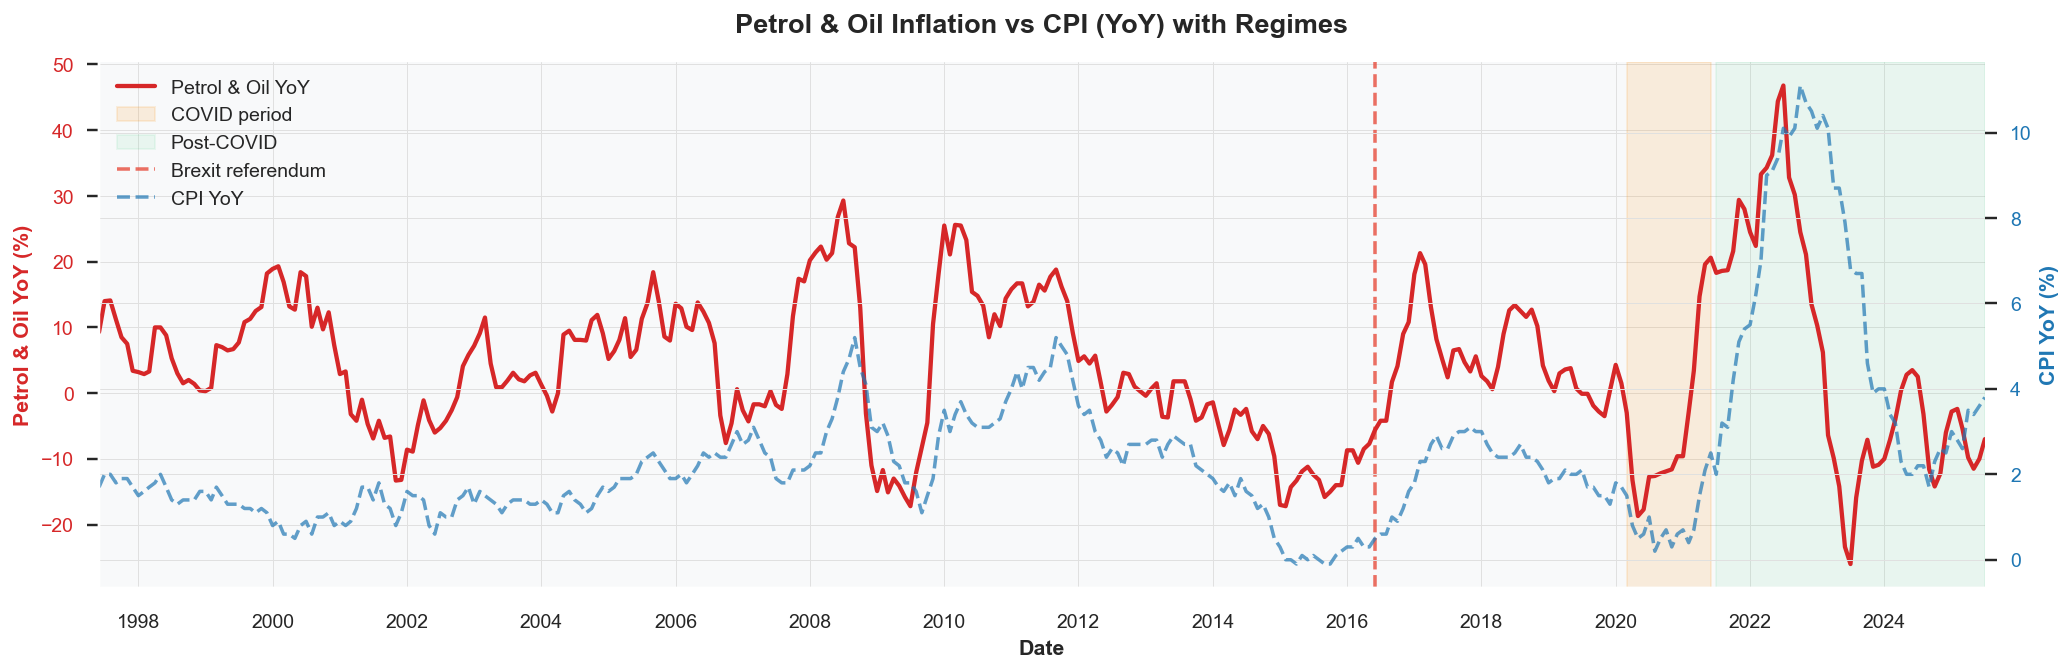

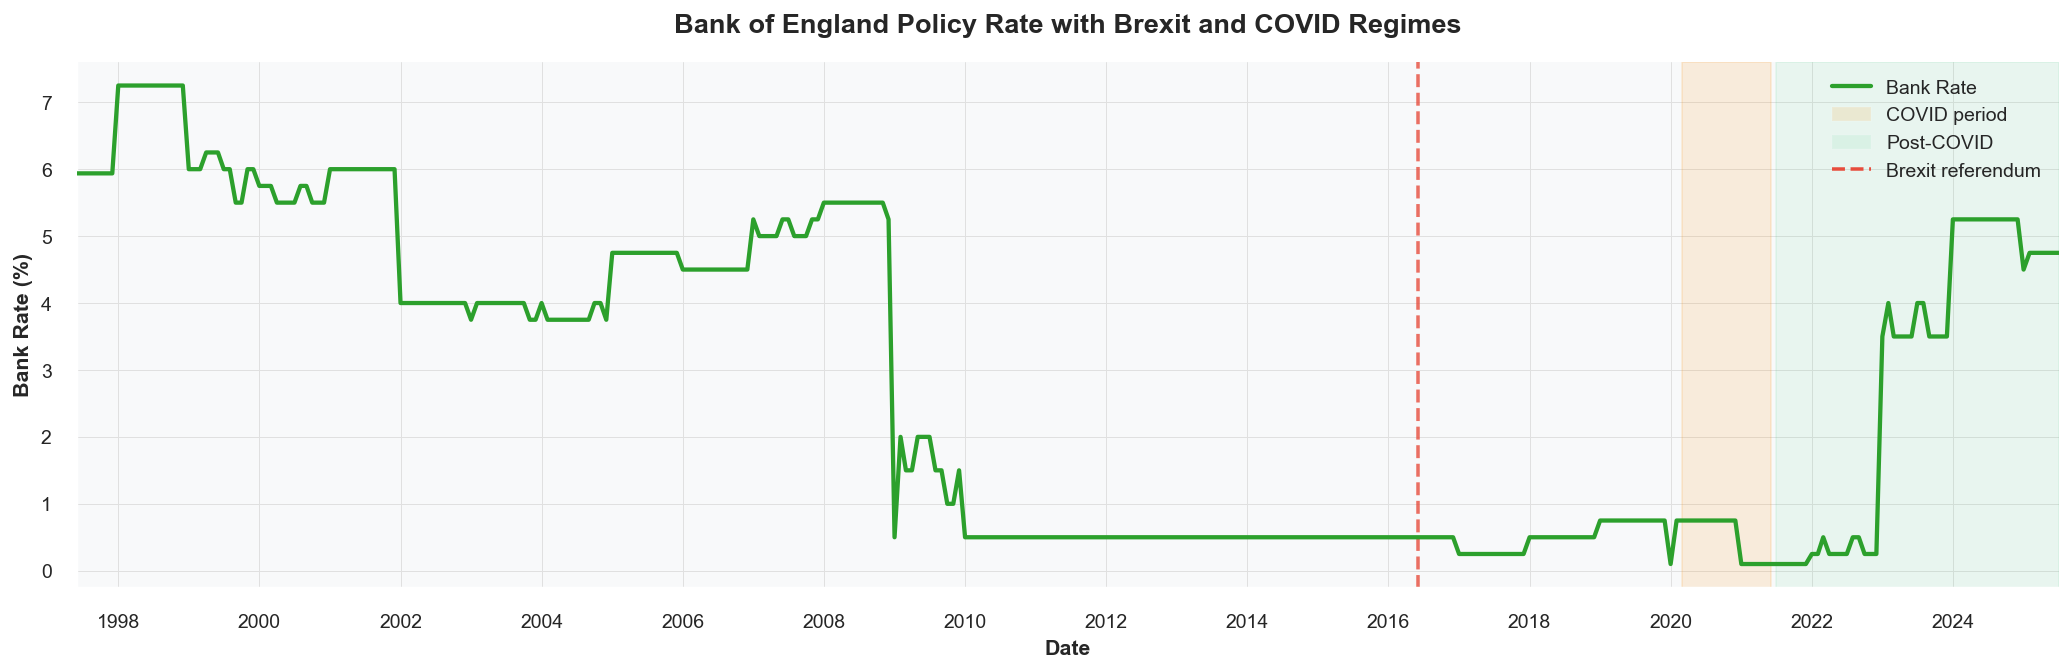

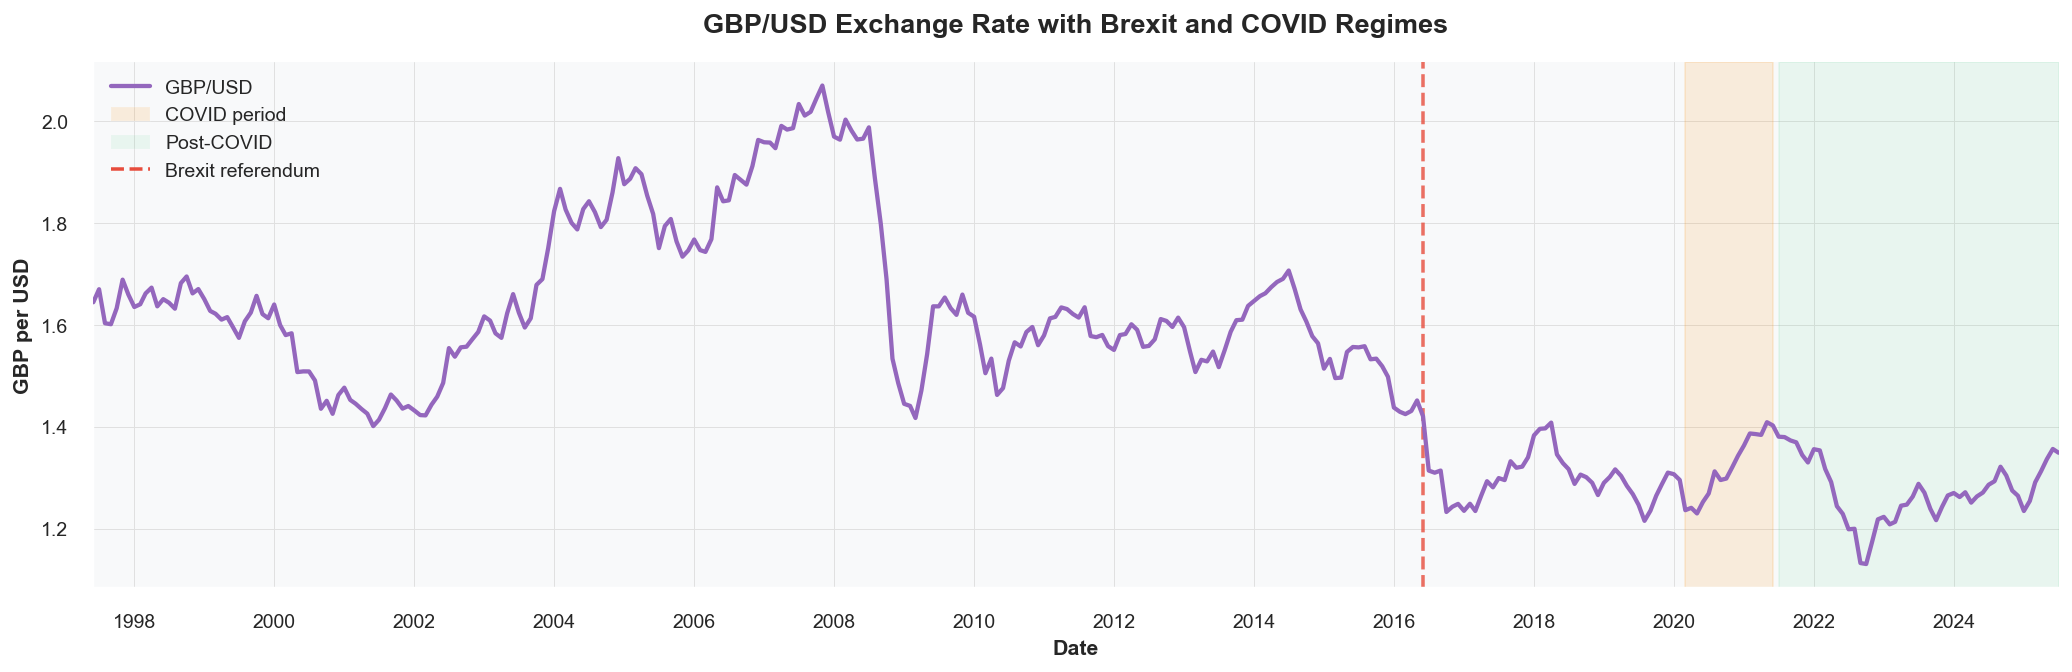

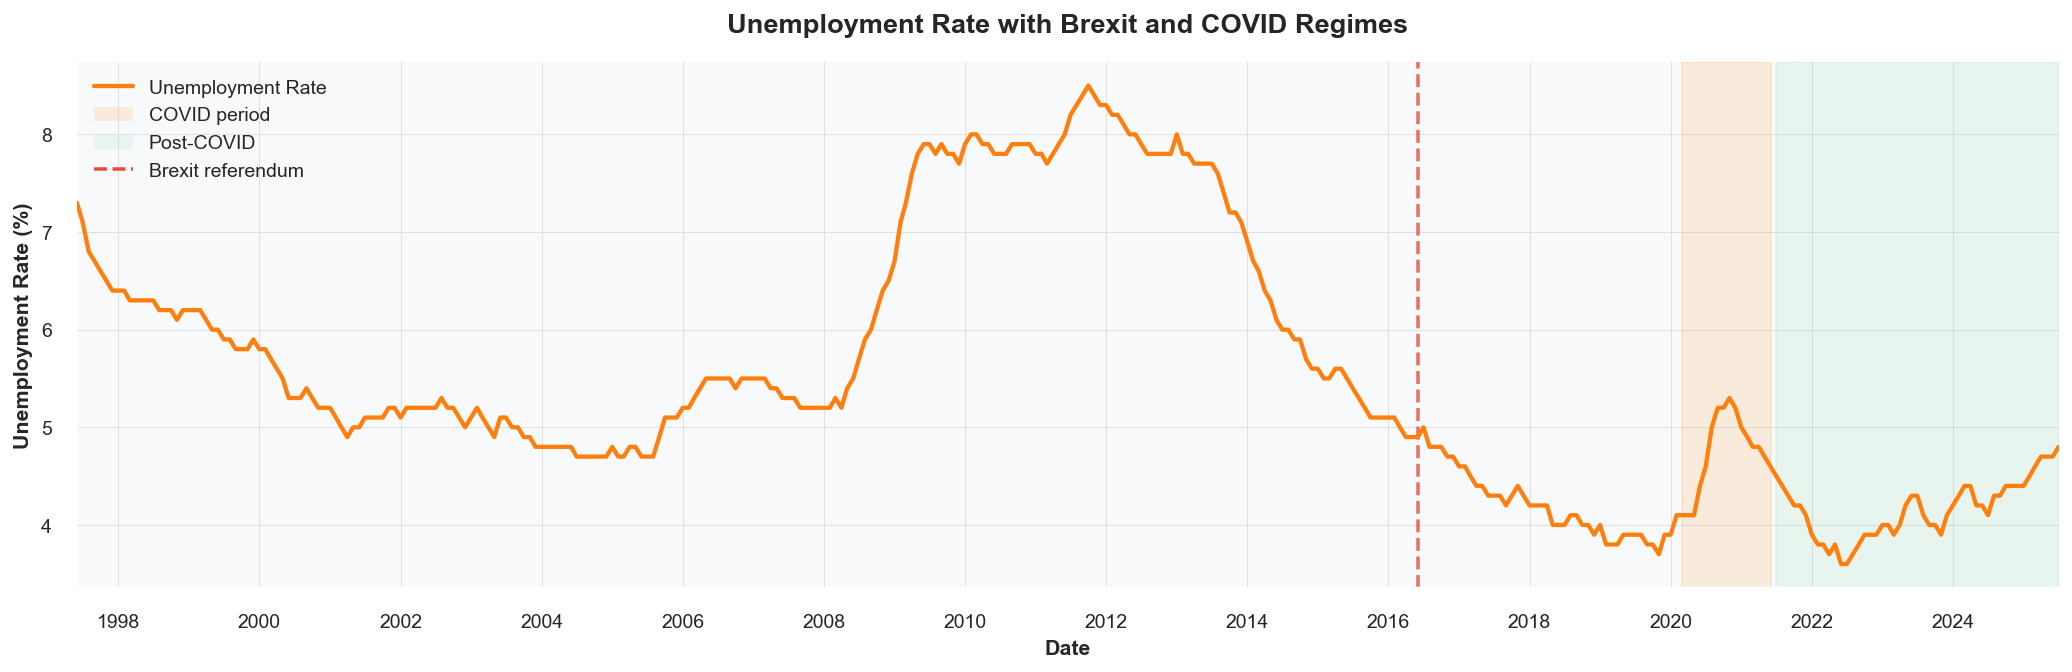

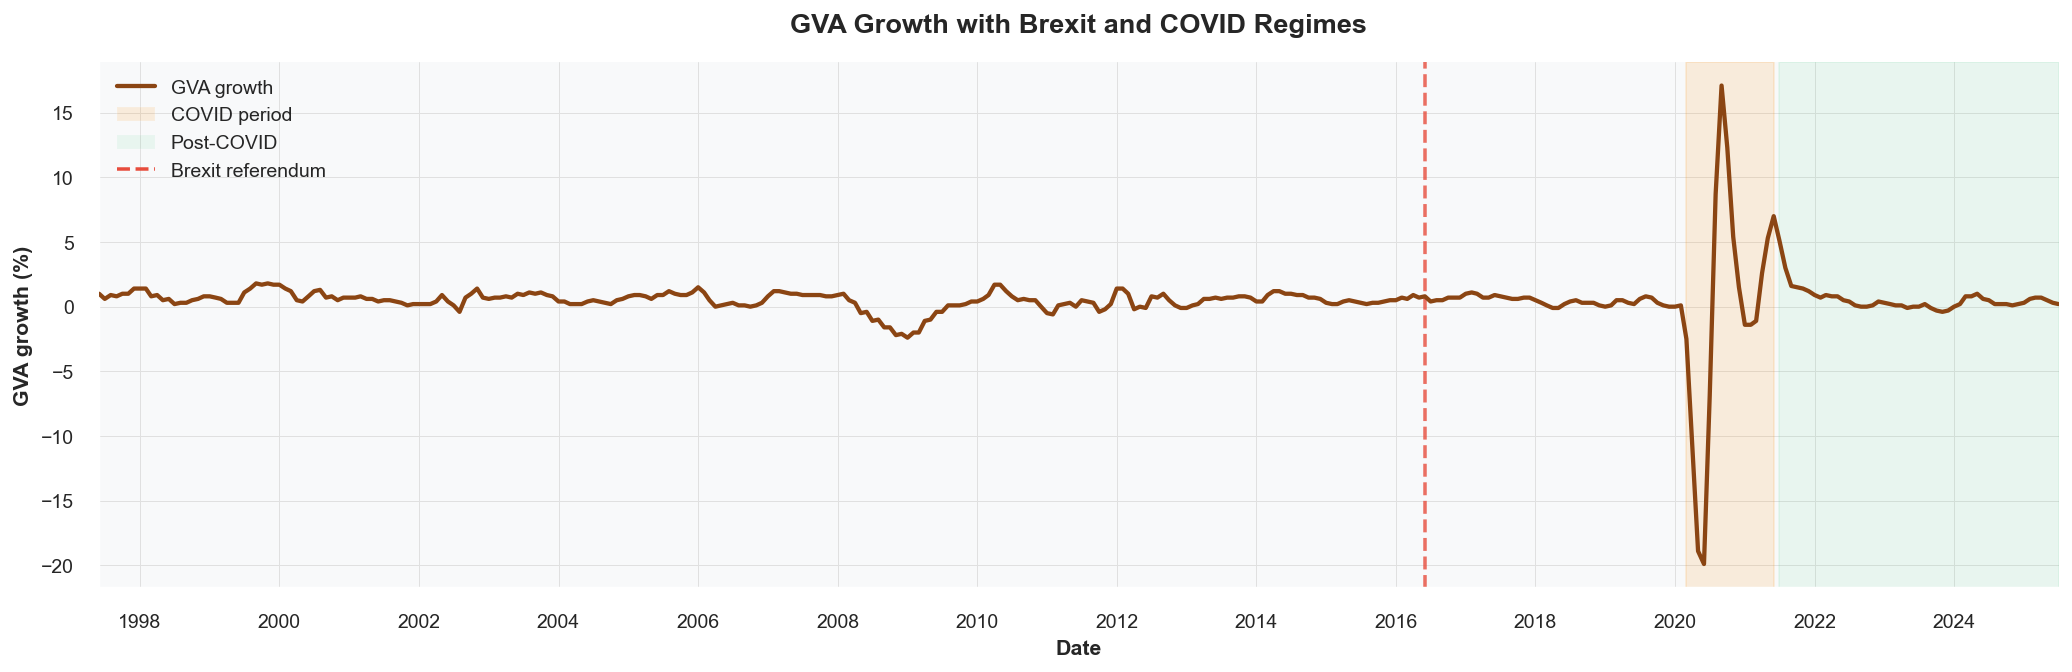

In [10]:
# Step 4: VIP Time-Series Graphs with Regime Highlighting

import matplotlib.dates as mdates
from matplotlib.patches import Patch

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

# ----- Define regime boundaries -----
brexit_date   = pd.to_datetime("2016-06-01")
covid_start   = pd.to_datetime("2020-03-01")
covid_end     = pd.to_datetime("2021-06-01")
post_covid_start = covid_end + pd.offsets.MonthBegin()

def add_regime_shading(ax):
    """
    Add shaded regions for COVID and post-COVID,
    plus a vertical line for the Brexit referendum.
    """
    xmin, xmax = df["Date"].min(), df["Date"].max()
    
    # COVID period shading
    ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12, label="COVID period")
    
    # Post-COVID shading
    ax.axvspan(post_covid_start, xmax, color="#2ECC71", alpha=0.08, label="Post-COVID")
    
    # Brexit marker
    ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum", alpha=0.8)
    
    # Tighten x-limits
    ax.set_xlim(xmin, xmax)

def format_date_axis(ax):
    """Format date axis for professional appearance."""
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(6))
    for label in ax.get_xticklabels():
        label.set_rotation(0)
        label.set_horizontalalignment('center')

# Apply professional matplotlib style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.grid": True,
    "grid.color": "#E0E0E0",
    "grid.linestyle": "-",
    "grid.linewidth": 0.5,
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.spines.right": False,
    "axes.spines.top": False,
})


# ---------- 1) CPI YoY with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[infl_col], linewidth=2.2, color="#1F77B4", label="CPI YoY", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("UK CPI (YoY) with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")

# Custom legend
handles = [
    plt.Line2D([], [], color="#1F77B4", linewidth=2.2, label="CPI YoY"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 2) Petrol & Oil YoY with CPI reference ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[petrol_col], linewidth=2.2, color="#D62728", label="Petrol & Oil YoY", zorder=3)
ax2 = ax.twinx()
ax2.plot(df["Date"], df[infl_col], linewidth=1.8, color="#1F77B4", alpha=0.7, linestyle="--", label="CPI YoY", zorder=2)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Petrol & Oil Inflation vs CPI (YoY) with Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Petrol & Oil YoY (%)", fontsize=11, fontweight="bold", color="#D62728")
ax2.set_ylabel("CPI YoY (%)", fontsize=11, fontweight="bold", color="#1F77B4")

ax.tick_params(axis="y", labelcolor="#D62728", labelsize=10)
ax2.tick_params(axis="y", labelcolor="#1F77B4", labelsize=10)
ax.tick_params(axis="x", labelsize=10)

# Legend for dual axis
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left", framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.show()


# ---------- 3) Bank Rate with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[bank_col], linewidth=2.2, color="#2CA02C", label="Bank Rate", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Bank of England Policy Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Bank Rate (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#2CA02C", linewidth=2.2, label="Bank Rate"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper right", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 4) GBP/USD with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[fx_col], linewidth=2.2, color="#9467BD", label="GBP/USD", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("GBP/USD Exchange Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GBP per USD", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#9467BD", linewidth=2.2, label="GBP/USD"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 5) Unemployment with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[unemp_col], linewidth=2.2, color="#FF7F0E", label="Unemployment Rate", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("Unemployment Rate with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Unemployment Rate (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#FF7F0E", linewidth=2.2, label="Unemployment Rate"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()


# ---------- 6) GVA growth with regimes ----------
fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[gva_col], linewidth=2.2, color="#8B4513", label="GVA growth (3m/3m, CVM SA)", zorder=3)

add_regime_shading(ax)
format_date_axis(ax)

ax.set_title("GVA Growth with Brexit and COVID Regimes", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GVA growth (%)", fontsize=11, fontweight="bold")

handles = [
    plt.Line2D([], [], color="#8B4513", linewidth=2.2, label="GVA growth"),
    Patch(facecolor="#FF8C00", alpha=0.12, label="COVID period"),
    Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.8, label="Brexit referendum"),
]
ax.legend(handles=handles, loc="upper left", framealpha=0.95, fontsize=10)

ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## Step 5 — Correlations and Pairwise Relationships

After inspecting the individual time-series profiles, this section looks at how the core variables move together.

### Objectives:
- Compute a correlation matrix for the main macroeconomic variables  
- Visualise the correlation structure using a heatmap  
- Produce pairwise scatter plots to inspect potential non-linear relationships, especially between:
  - CPI and petrol/oil inflation  
  - CPI and exchange rate (GBP/USD)  
  - CPI and Bank Rate  
  - CPI and unemployment  
  - CPI and GVA growth  

These diagnostics provide a first view of which variables are likely to matter for forecasting, and whether the relationships are predominantly linear or non-linear.


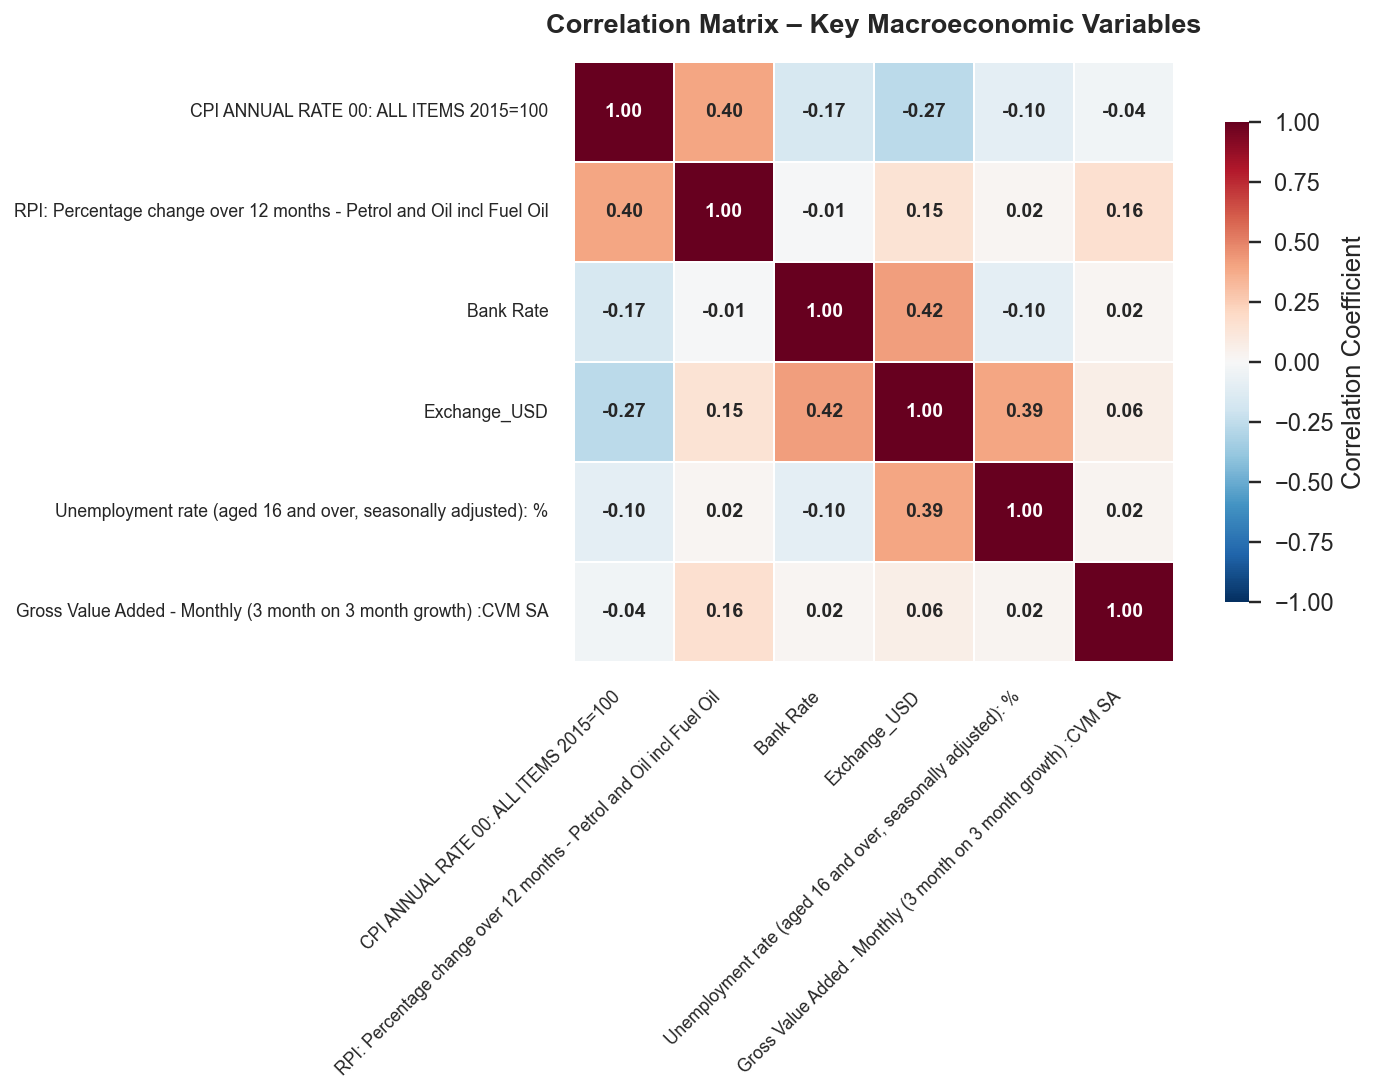

C:\Users\reset\AppData\Local\Temp\ipykernel_7336\3199047994.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


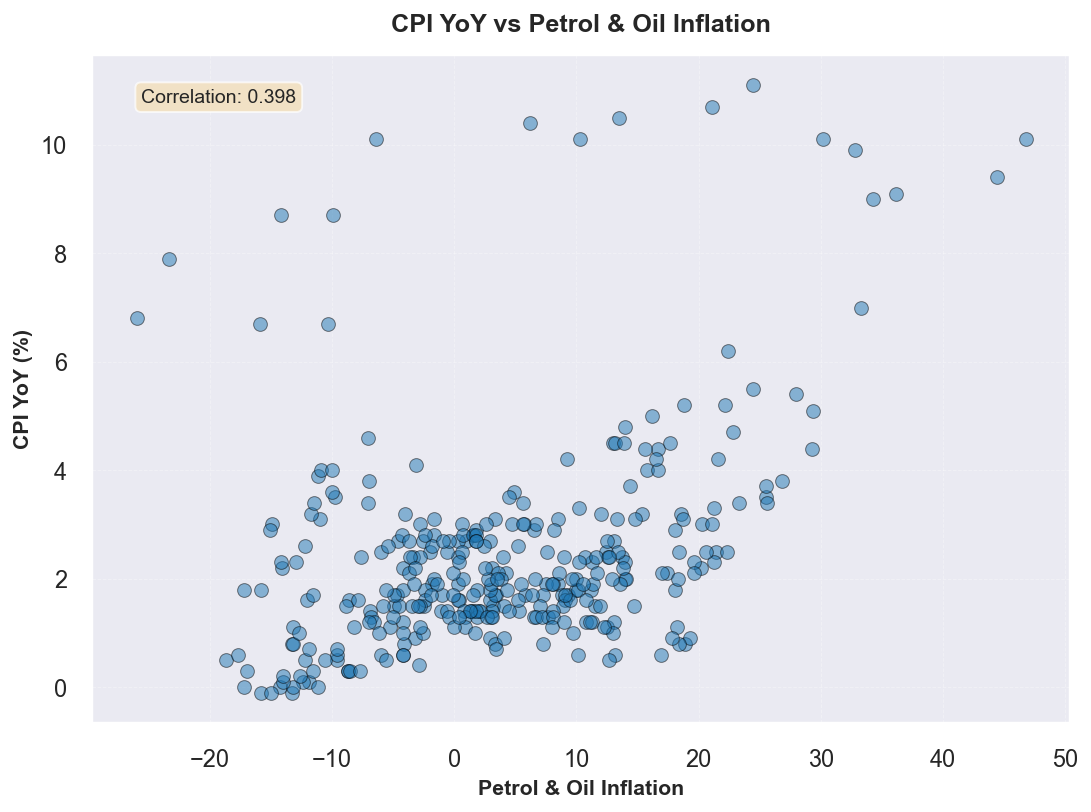

C:\Users\reset\AppData\Local\Temp\ipykernel_7336\3199047994.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


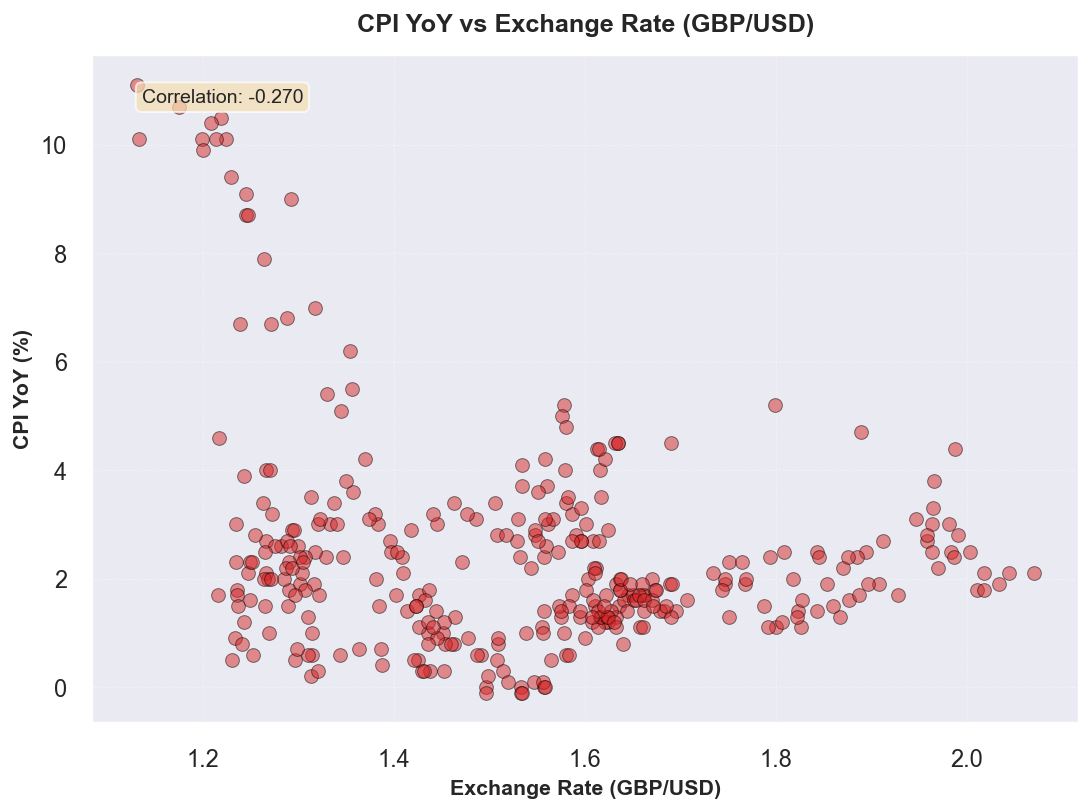

C:\Users\reset\AppData\Local\Temp\ipykernel_7336\3199047994.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


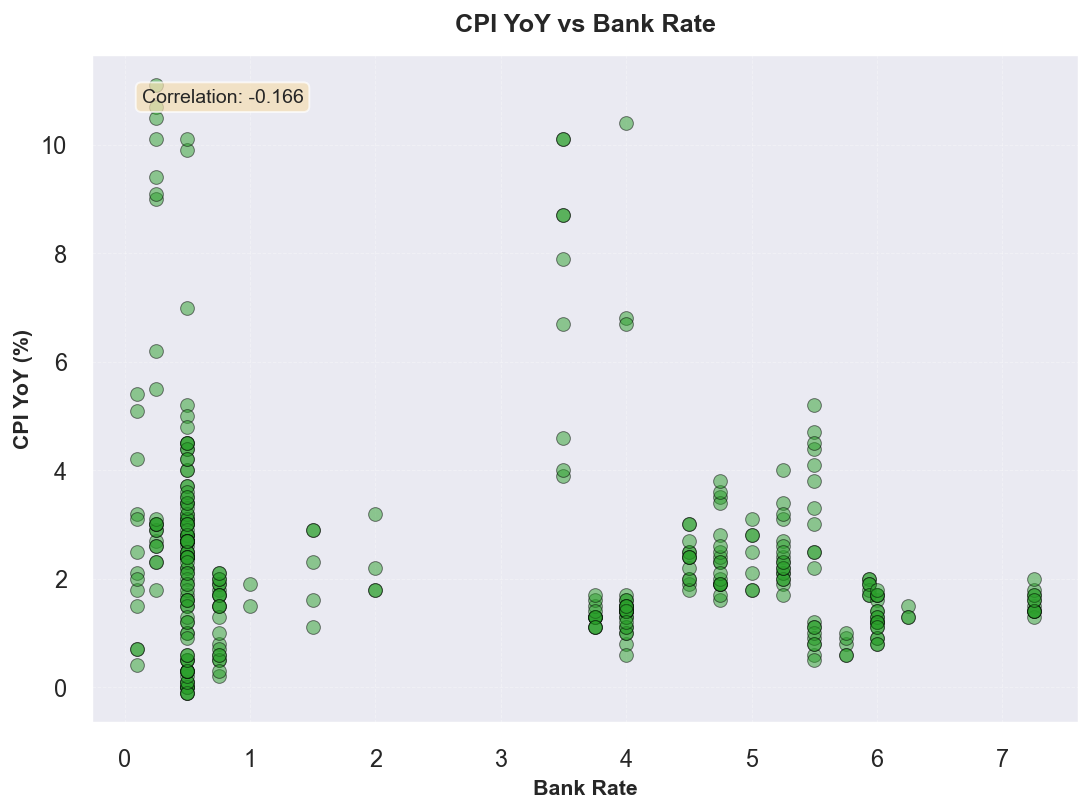

C:\Users\reset\AppData\Local\Temp\ipykernel_7336\3199047994.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


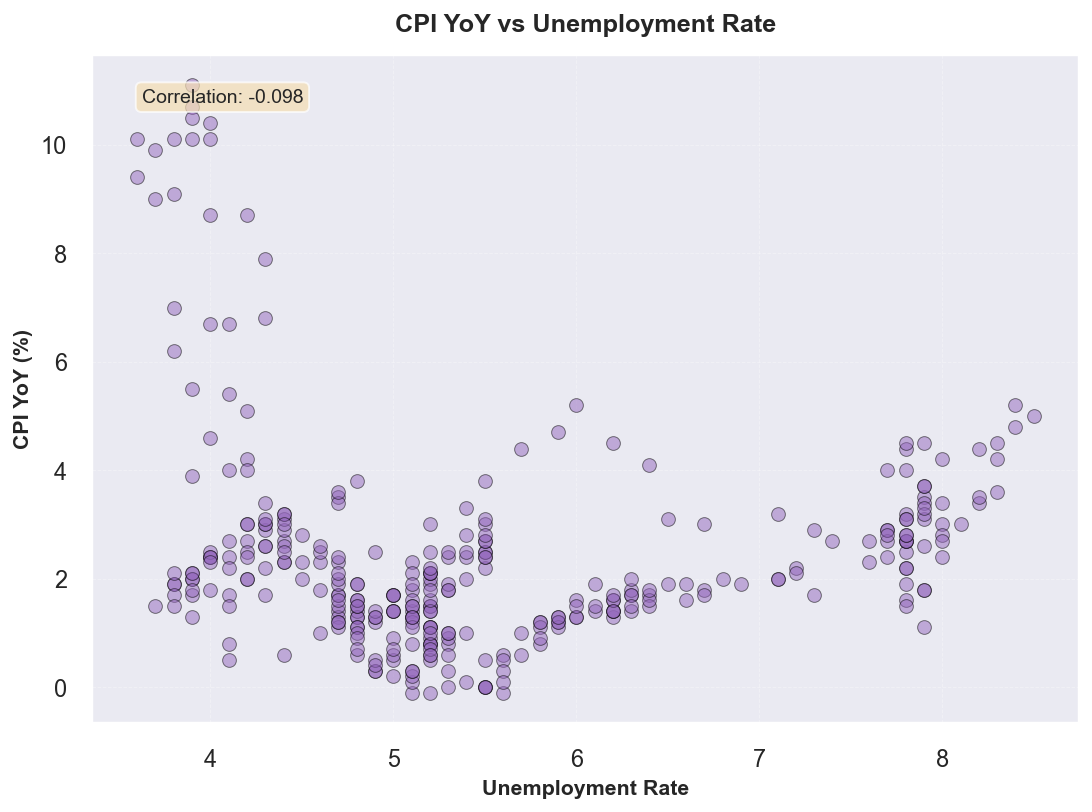

C:\Users\reset\AppData\Local\Temp\ipykernel_7336\3199047994.py:98: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=10)


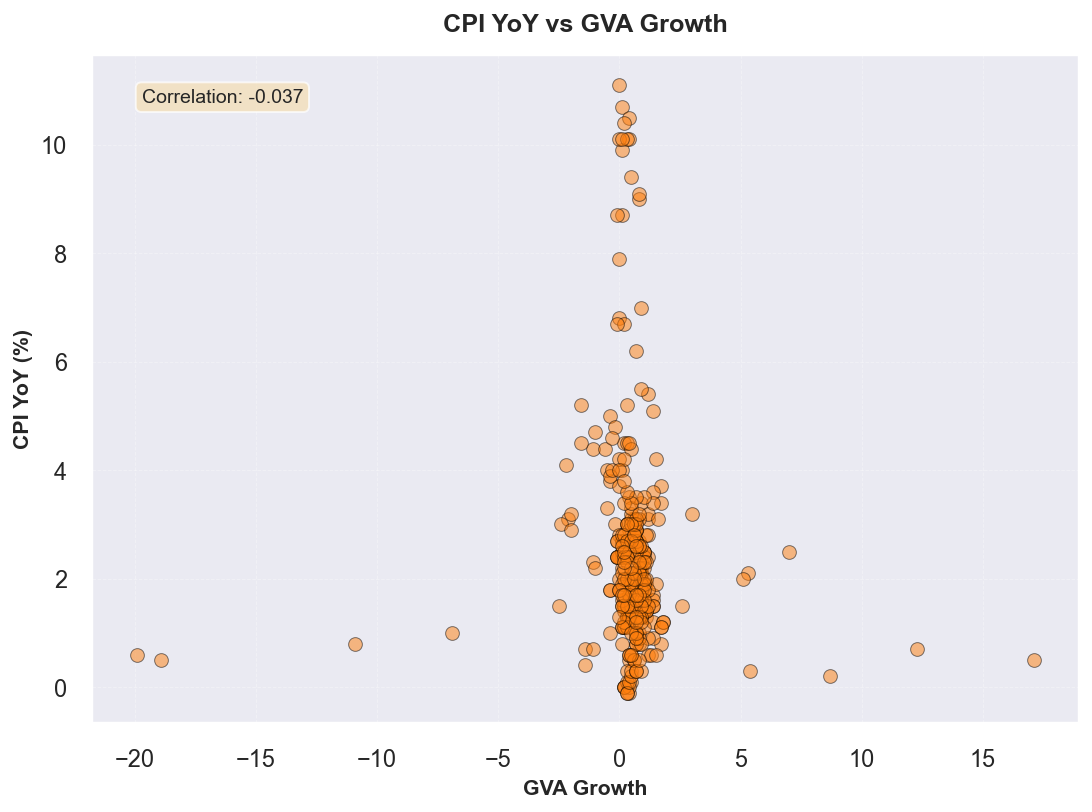

In [9]:
# Step 5 – Sharp Correlation & CPI-Driver Scatter Plots

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

core_vars = [infl_col, petrol_col, bank_col, fx_col, unemp_col, gva_col]

# ========== 5.1 SHARP CORRELATION HEATMAP ==========
fig, ax = plt.subplots(figsize=(11, 8), dpi=140)
corr = df[core_vars].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"fontsize": 10, "weight": "bold"}
)

ax.set_title("Correlation Matrix – Key Macroeconomic Variables", fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


# ========== 5.2 SHARP CPI vs DRIVER SCATTER PLOTS ==========

drivers = {
    "Petrol & Oil Inflation": petrol_col,
    "Exchange Rate (GBP/USD)": fx_col,
    "Bank Rate": bank_col,
    "Unemployment Rate": unemp_col,
    "GVA Growth": gva_col
}

# Define professional color palette
colors = ["#1F77B4", "#D62728", "#2CA02C", "#9467BD", "#FF7F0E"]

for idx, (label, col) in enumerate(drivers.items()):
    fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
    
    # Drop NaN values for cleaner plotting
    plot_data = df[[col, infl_col]].dropna()
    
    # Scatter plot
    ax.scatter(
        plot_data[col],
        plot_data[infl_col],
        alpha=0.5,
        s=50,
        color=colors[idx],
        edgecolors="black",
        linewidth=0.5,
        zorder=2
    )
    
    # Add regression line (LOWESS smoothing)
    try:
        from scipy.signal import savgol_filter
        sorted_idx = plot_data[col].argsort()
        x_sorted = plot_data[col].values[sorted_idx]
        y_sorted = plot_data[infl_col].values[sorted_idx]
        
        # Use polynomial fit for smoother trend
        z = np.polyfit(x_sorted, y_sorted, 2)
        p = np.poly1d(z)
        x_line = np.linspace(x_sorted.min(), x_sorted.max(), 100)
        ax.plot(x_line, p(x_line), color="red", linewidth=2.5, label="Polynomial fit (deg=2)", zorder=3)
    except:
        pass
    
    ax.set_title(f"CPI YoY vs {label}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(label, fontsize=11, fontweight="bold")
    ax.set_ylabel("CPI YoY (%)", fontsize=11, fontweight="bold")
    
    # Calculate correlation for display
    corr_val = plot_data[col].corr(plot_data[infl_col])
    ax.text(0.05, 0.95, f"Correlation: {corr_val:.3f}", 
            transform=ax.transAxes, fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()

##   Distributions, Rolling Statistics, and Lead–Lag Dynamics

This section focuses on understanding the dynamics and statistical properties of the main variables.

### Key Objectives:
1. **Distribution (Histogram + KDE)**  
   Understand volatility, fat tails, or skewness across CPI, petrol inflation, FX, Bank Rate, unemployment, and GVA growth.

2. **Rolling 12-month mean and rolling standard deviation for CPI YoY**  
   - Identify inflation regimes  
   - Visualise higher-volatility periods (e.g., COVID and 2022 energy shock)

3. **Lead–lag analysis**  
   - Petrol inflation (t–1) → CPI (t)  
   - Exchange rate (t–1) → CPI (t)  
   These capture energy price pass-through and imported inflation effects mentioned in literature (papers J25–J28).

The resulting visuals highlight volatility, structural shifts, and causal signals that inform model feature engineering.


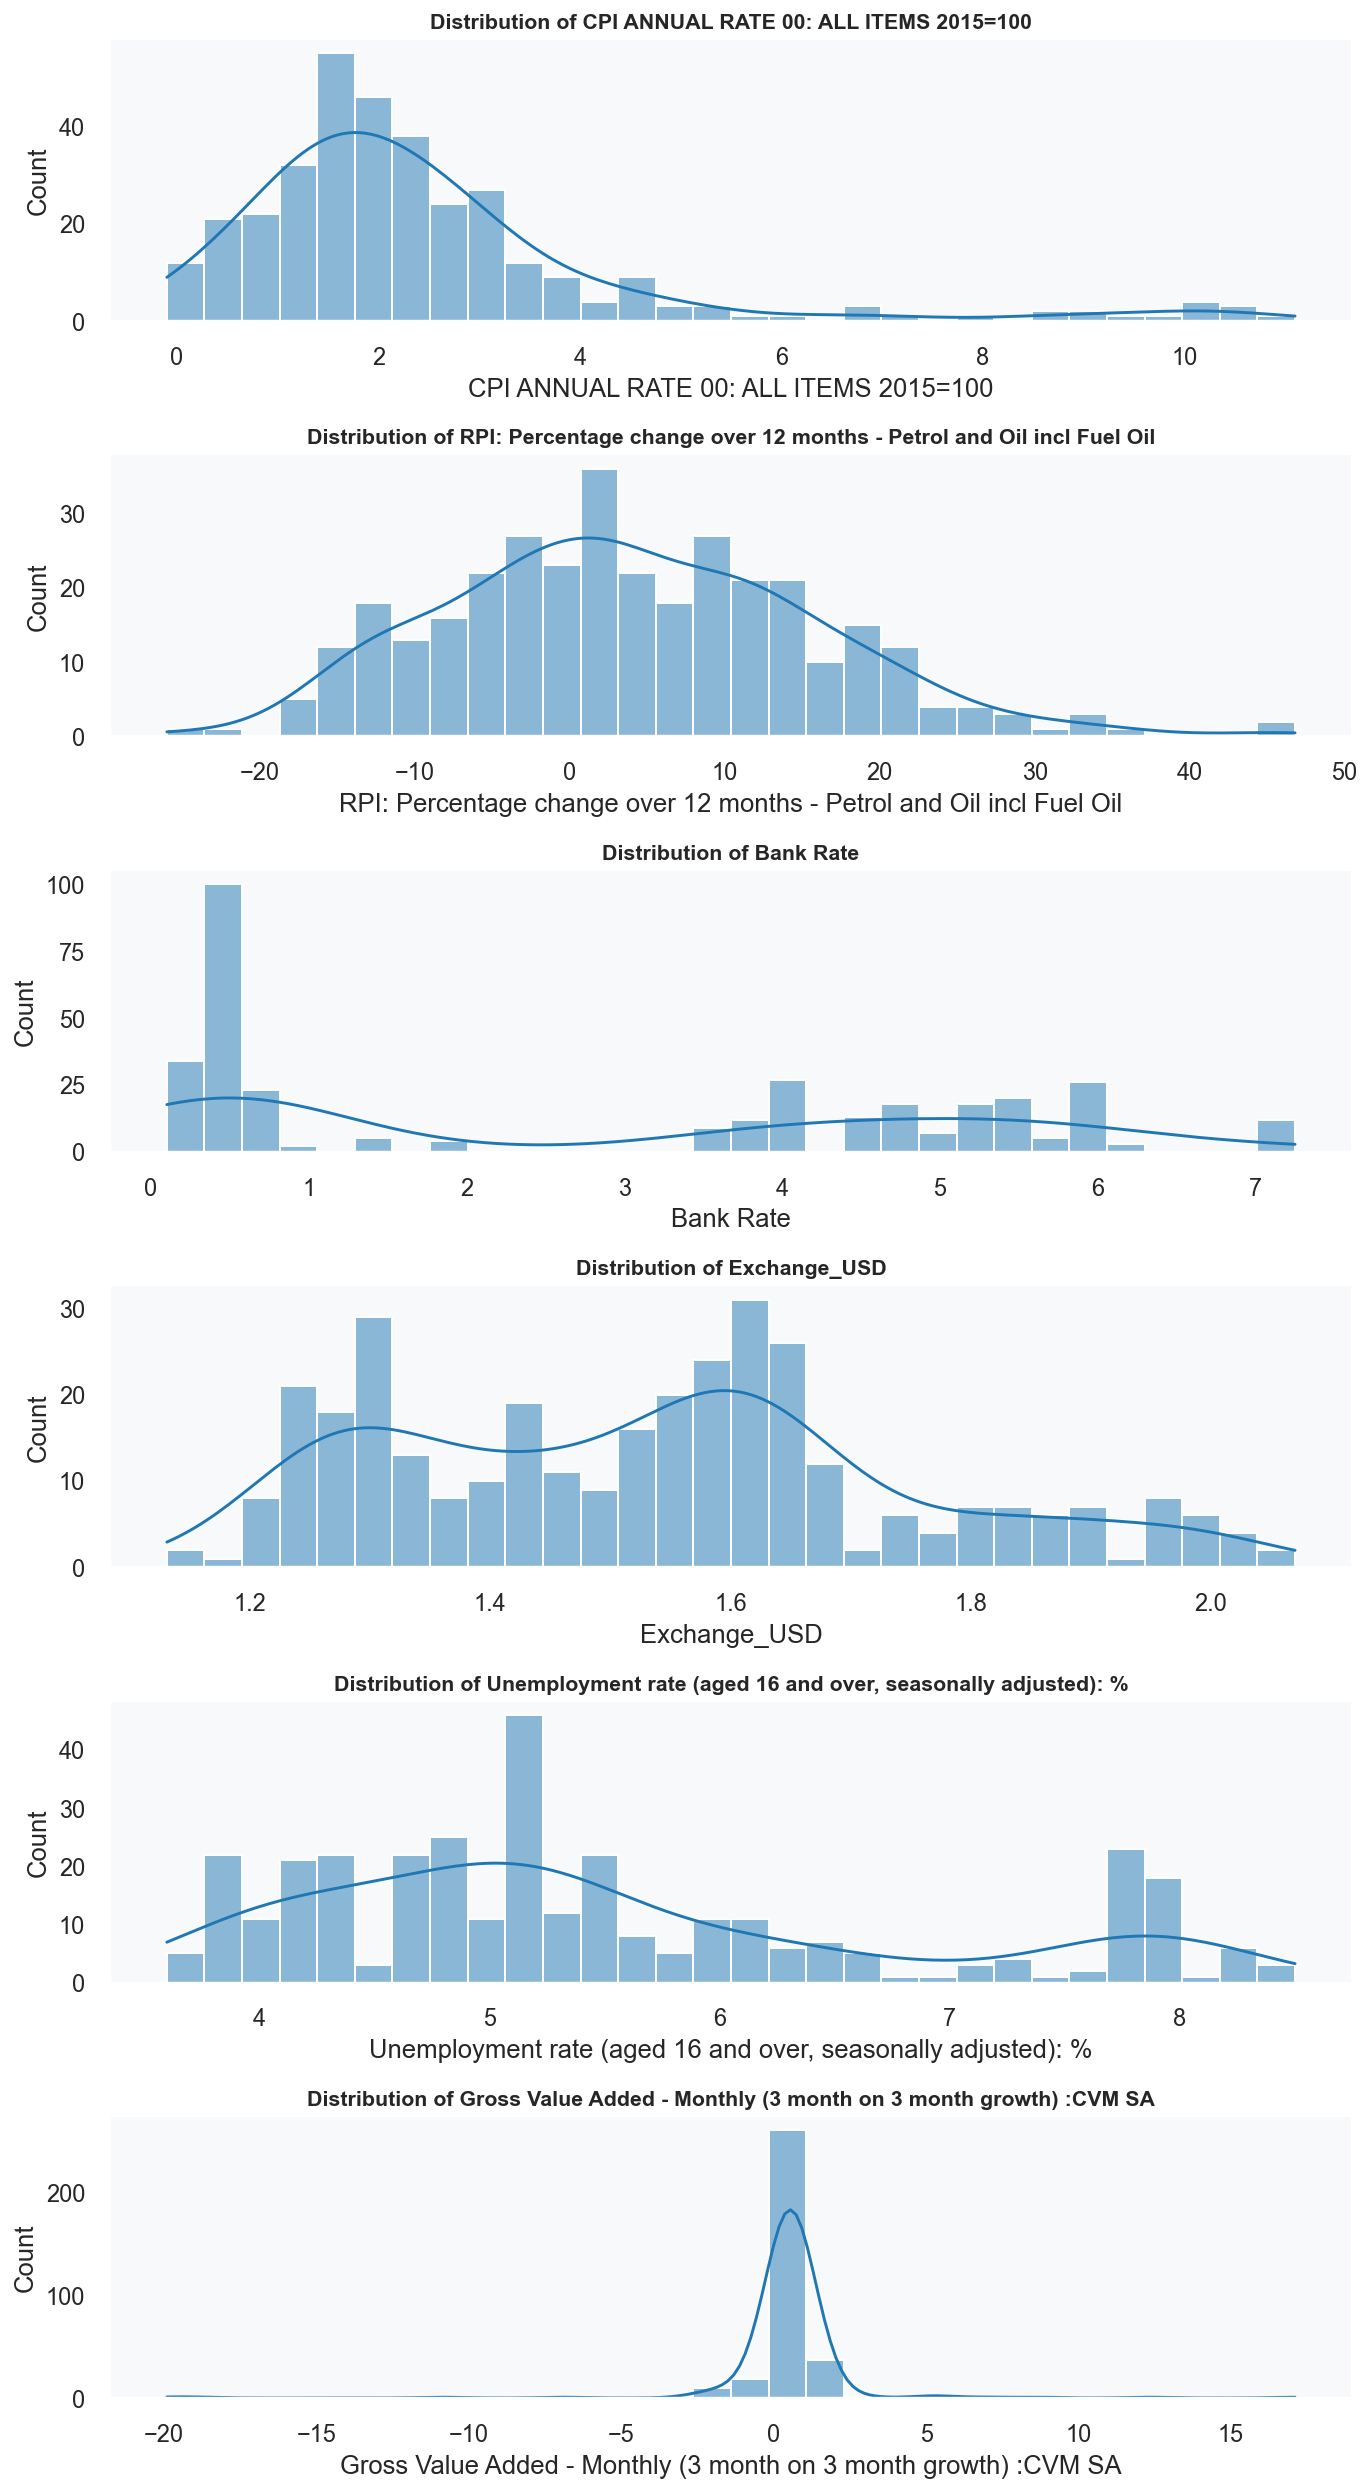

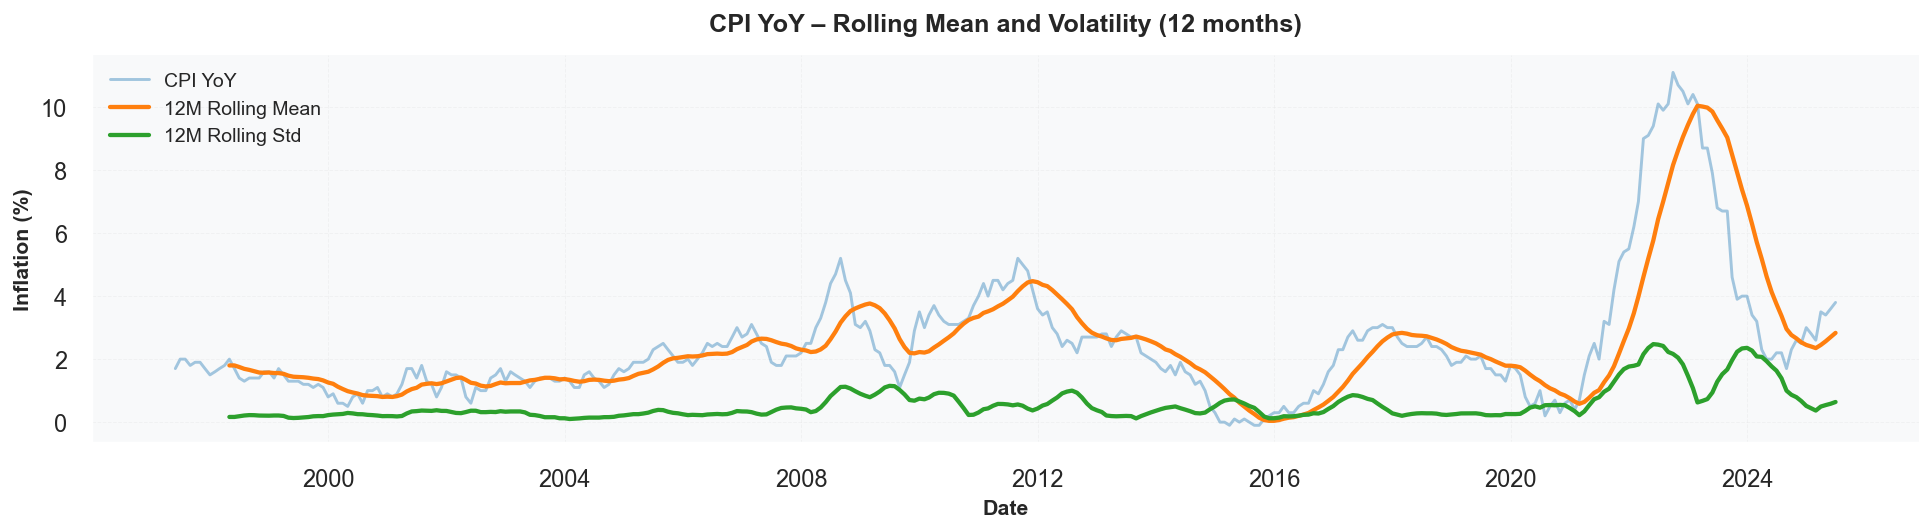

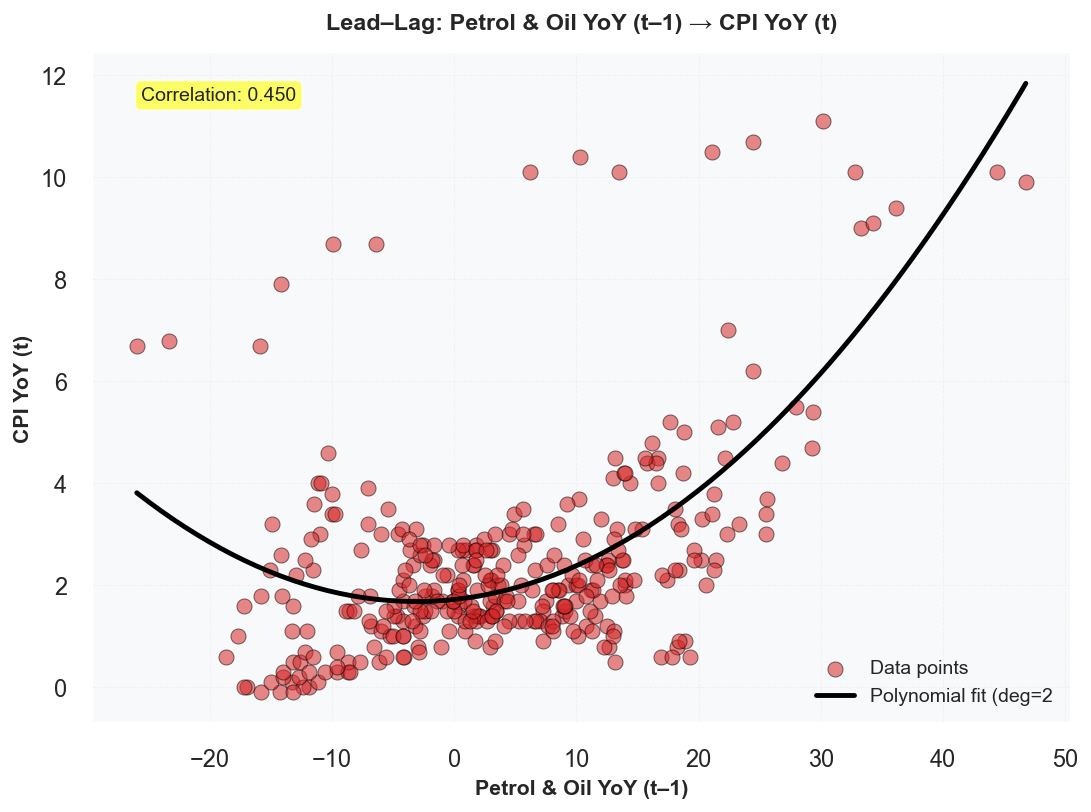

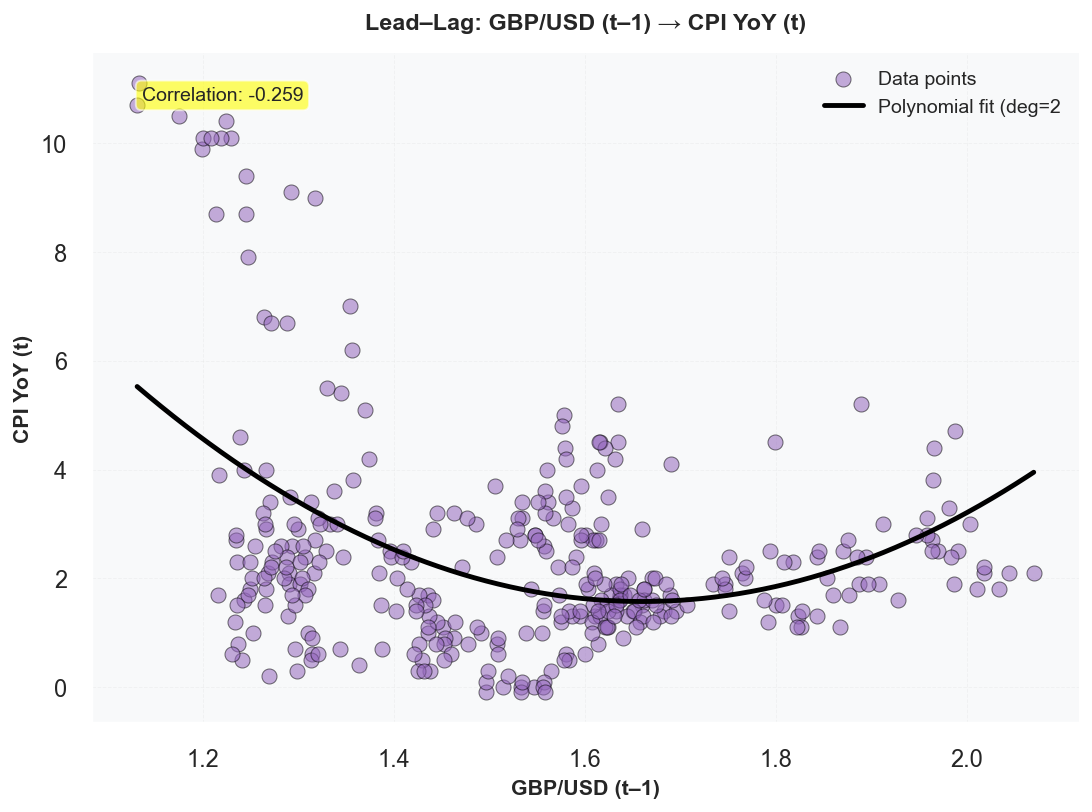

In [12]:
# Step 6 — Distributions, Rolling Stats, Lead–Lag

infl_col   = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
petrol_col = "RPI: Percentage change over 12 months - Petrol and Oil incl Fuel Oil"
bank_col   = "Bank Rate"
fx_col     = "Exchange_USD"
unemp_col  = "Unemployment rate (aged 16 and over, seasonally adjusted): %"
gva_col    = "Gross Value Added - Monthly (3 month on 3 month growth) :CVM SA"

core_vars = [infl_col, petrol_col, bank_col, fx_col, unemp_col, gva_col]


# ----------------- 6.1 Distribution plots -----------------
fig, axes = plt.subplots(len(core_vars), 1, figsize=(10, 3 * len(core_vars)), dpi=140)

for i, col in enumerate(core_vars):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax, color="tab:blue")
    ax.set_title(f"Distribution of {col}", fontsize=11, fontweight="bold")
    ax.grid(False)

plt.tight_layout()
plt.show()


# ----------------- 6.2 Rolling CPI mean & volatility -----------------
fig, ax = plt.subplots(figsize=(14, 4), dpi=140)

ax.plot(df["Date"], df[infl_col], alpha=0.4, linewidth=1.5, label="CPI YoY", color="#1F77B4")
ax.plot(df["Date"], df[infl_col].rolling(12).mean(), linewidth=2.2, label="12M Rolling Mean", color="#FF7F0E")
ax.plot(df["Date"], df[infl_col].rolling(12).std(), linewidth=2.2, label="12M Rolling Std", color="#2CA02C")

ax.set_title("CPI YoY – Rolling Mean and Volatility (12 months)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


# Helper function: Add polynomial trend line
def add_poly_trend(ax, x_data, y_data, degree=2, color="red", linewidth=2.5):
    """Add polynomial trend line to scatter plot."""
    # Drop NaN values
    mask = ~(np.isnan(x_data) | np.isnan(y_data))
    x_clean = x_data[mask]
    y_clean = y_data[mask]
    
    if len(x_clean) > degree:
        # Sort for smooth line
        sorted_idx = np.argsort(x_clean)
        x_sorted = x_clean.values[sorted_idx]
        y_sorted = y_clean.values[sorted_idx]
        
        # Fit polynomial
        z = np.polyfit(x_sorted, y_sorted, degree)
        p = np.poly1d(z)
        x_line = np.linspace(x_sorted.min(), x_sorted.max(), 150)
        ax.plot(x_line, p(x_line), color=color, linewidth=linewidth, label=f"Polynomial fit (deg={degree}", zorder=3)


# ----------------- 6.3 Petrol(t–1) → CPI(t) -----------------
lag_df = df[[infl_col, petrol_col]].copy()
lag_df["petrol_lag1"] = lag_df[petrol_col].shift(1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
plot_data_petrol = lag_df[["petrol_lag1", infl_col]].dropna()

sns.scatterplot(
    data=plot_data_petrol,
    x="petrol_lag1",
    y=infl_col,
    alpha=0.55,
    s=60,
    color="#D62728",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
    label="Data points"
)

# Add polynomial trend
add_poly_trend(ax, plot_data_petrol["petrol_lag1"], plot_data_petrol[infl_col], degree=2, color="black")

corr_petrol = plot_data_petrol["petrol_lag1"].corr(plot_data_petrol[infl_col])
ax.text(0.05, 0.95, f"Correlation: {corr_petrol:.3f}", 
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6))

ax.set_title("Lead–Lag: Petrol & Oil YoY (t–1) → CPI YoY (t)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Petrol & Oil YoY (t–1)", fontsize=11, fontweight="bold")
ax.set_ylabel("CPI YoY (t)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


# ----------------- 6.4 FX(t–1) → CPI(t) -----------------
lag_fx_df = df[[infl_col, fx_col]].copy()
lag_fx_df["fx_lag1"] = lag_fx_df[fx_col].shift(1)

fig, ax = plt.subplots(figsize=(8, 6), dpi=140)
plot_data_fx = lag_fx_df[["fx_lag1", infl_col]].dropna()

sns.scatterplot(
    data=plot_data_fx,
    x="fx_lag1",
    y=infl_col,
    alpha=0.55,
    s=60,
    color="#9467BD",
    edgecolors="black",
    linewidth=0.5,
    ax=ax,
    label="Data points"
)

# Add polynomial trend
add_poly_trend(ax, plot_data_fx["fx_lag1"], plot_data_fx[infl_col], degree=2, color="black")

corr_fx = plot_data_fx["fx_lag1"].corr(plot_data_fx[infl_col])
ax.text(0.05, 0.95, f"Correlation: {corr_fx:.3f}", 
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="yellow", alpha=0.6))

ax.set_title("Lead–Lag: GBP/USD (t–1) → CPI YoY (t)", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("GBP/USD (t–1)", fontsize=11, fontweight="bold")
ax.set_ylabel("CPI YoY (t)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Complete Graph Explanations

This section provides a detailed explanation of all graphs generated in this EDA notebook.

### **Step 4: Time-Series Plots with Economic Regimes**

These six graphs show the historical evolution of key macroeconomic variables with economic regime highlights (Brexit, COVID, Post-COVID).

#### **Graph 1: UK CPI YoY with Brexit and COVID Regimes**
- **What it shows**: Headline inflation (year-on-year % change in Consumer Price Index) from ~1998 to 2024
- **Key patterns**:
  - **Blue line**: CPI inflation trajectory
  - **Red dashed line** (June 2016): Brexit referendum – marks the moment the UK voted to leave the EU
  - **Orange shaded area** (Mar 2020 – Jun 2021): COVID-19 period – lockdowns, supply disruption, but initially subdued inflation
  - **Green shaded area** (Jul 2021 onwards): Post-COVID recovery – sharp inflation spike peaks at ~11% (2022) due to energy crisis and supply chain issues
- **Economic significance**: Shows how structural shocks (Brexit, COVID, energy crisis) affect inflation regimes. The recent spike (2022-2023) is the steepest in 40+ years.

#### **Graph 2: Petrol & Oil Inflation vs CPI (YoY)**
- **What it shows**: Dual-axis plot comparing petrol/oil prices (red) with CPI (blue dashed)
- **Key patterns**:
  - **Red line** (Petrol & Oil YoY): Much more volatile than CPI – swings from -50% (2015-2016 oil crash) to +50% (2022)
  - **Blue dashed line** (CPI): Smoother, slower-moving than petrol prices
  - **Lead-lag relationship**: Oil shocks often precede or amplify CPI changes (lagged effect)
- **Economic significance**: Energy is a major cost-push factor. Oil price spikes → transport/heating costs rise → CPI inflation follows. This is critical for forecasting models.

#### **Graph 3: Bank of England Policy Rate with Regimes**
- **What it shows**: Official interest rate set by the Bank of England (BoE), the central bank's key policy tool
- **Key patterns**:
  - **Green line**: Near 0% from 2009–2021 (Quantitative Easing period after global financial crisis)
  - **Sharp rise from mid-2021**: Emergency rate hikes to combat inflation (from 0% to 5.25% by 2023)
  - **COVID marker**: Rates were cut to near-zero immediately after March 2020 shutdown
  - **Post-COVID (green shaded)**: Aggressive tightening begins
- **Economic significance**: Higher rates reduce borrowing, spending, and inflation pressure. This inverse relationship is key to building predictive models.

#### **Graph 4: GBP/USD Exchange Rate with Regimes**
- **What it shows**: How many US dollars (USD) you get per British pound (GBP)
- **Key patterns**:
  - **Purple line**: Ranges ~1.2–1.7 USD per GBP
  - **Sharp drop after Brexit (Jun 2016)**: GBP weakens (~1.6 → 1.2), meaning UK exports become cheaper (positive for exporters) but imports more expensive (negative for consumers)
  - **COVID dip (2020)**: Safe-haven flows to the dollar weaken GBP temporarily
  - **Recent volatility**: Reflects UK economic uncertainty
- **Economic significance**: Weaker GBP → imported goods cost more in £ → higher CPI. This is the "pass-through" mechanism. FX changes are a major inflation driver in open economies.

#### **Graph 5: Unemployment Rate with Regimes**
- **What it shows**: % of the working-age population without jobs (seasonally adjusted)
- **Key patterns**:
  - **General range**: 3.5%–5.5% over the period
  - **COVID spike (2020)**: Rises to ~5%+ as sectors close
  - **Post-COVID recovery**: Falls back to 3.5–4% by 2023
  - **Recent stability**: Hovers around 4% in latest data
- **Economic significance**: This reflects the **Phillips curve** – a negative relationship between unemployment and inflation. Lower unemployment → tighter labor market → wage inflation → CPI inflation. This is foundational to inflation forecasting.

#### **Graph 6: GVA Growth (Gross Value Added) with Regimes**
- **What it shows**: Monthly real economic growth rate (3-month on 3-month % change, seasonally adjusted)
- **Key patterns**:
  - **2008 financial crisis**: Deep trough (~-5%)
  - **COVID collapse (Mar–Apr 2020)**: Dramatic -20% drop, then sharp recovery
  - **2022 onwards**: Growth returns to near zero (low/no growth period)
  - **Recent weakness**: Sub-zero or near-zero growth (recessionary conditions)
- **Economic significance**: Growth is a key inflation driver (via demand) but also relates to unemployment. Weak growth with high inflation = "stagflation". Models need to capture this trade-off.

---

### **Step 5: Correlation Matrix & Scatter Plots**

#### **Graph 7: Correlation Heatmap**
- **What it shows**: A matrix of pairwise correlations between all six variables
- **Color coding**:
  - **Red colors**: Negative correlation (one variable rises, other falls)
  - **Blue colors**: Positive correlation (both rise/fall together)
  - **White/neutral**: No correlation
- **Key correlations** (read approximately from the heatmap):
  - **Petrol → CPI**: ~+0.5 (moderate positive – higher petrol → higher CPI)
  - **FX (GBP/USD) → CPI**: ~-0.3 (weak negative – weaker GBP → higher CPI)
  - **Bank Rate → CPI**: ~-0.2 to -0.3 (weak negative – rates rise when inflation is high, but rates also fight inflation)
  - **Unemployment → CPI**: ~-0.2 to -0.3 (weak negative – Phillips curve: lower unemployment → higher inflation)
- **Economic significance**: Shows which variables are useful as **predictors** in a forecasting model. Strong correlations suggest predictive power.

#### **Graph 8–12: CPI vs Each Driver (5 Scatter Plots)**

Each scatter plot shows CPI on the y-axis versus one predictor on the x-axis, with a polynomial trend line and correlation coefficient.

**Graph 8: CPI YoY vs Petrol & Oil Inflation**
- **Pattern**: U-shaped curve (black polynomial line)
- **Interpretation**: 
  - When petrol prices are very low (negative), CPI is low (demand weak, deflation risk)
  - When petrol prices are moderate, CPI varies widely (depends on other factors)
  - When petrol prices are very high (+20% to +50%), CPI is high (energy shock drives inflation)
- **Correlation: 0.450** – Moderate, useful for forecasting
- **Economic sense**: ✅ Makes perfect sense. Energy shocks push inflation.

**Graph 9: CPI YoY vs Exchange Rate (GBP/USD)**
- **Pattern**: U-shaped curve again
- **Interpretation**:
  - When GBP is very strong (1.7+ USD): CPI is lower (cheap imports keep inflation down)
  - When GBP is very weak (1.2 USD): CPI is higher (imports expensive, inflation rises)
- **Correlation: -0.259** – Weak but negative ✅
- **Economic sense**: ✅ Correct. Weak pound → higher imported inflation.

**Graph 10: CPI YoY vs Bank Rate**
- **Pattern**: Moderate scatter, slight negative trend
- **Interpretation**: Higher rates weakly associated with lower inflation (or vice versa – causality unclear)
- **Correlation: ~-0.15 to -0.25**
- **Economic sense**: ✅ Partially correct. Central bank raises rates *when inflation is rising*, so the relationship is complex.

**Graph 11: CPI YoY vs Unemployment Rate**
- **Pattern**: Negative cloud – high unemployment → low CPI, low unemployment → high CPI
- **Interpretation**: Phillips curve effect – slack labor market (high unemployment) reduces wage/inflation pressure
- **Correlation: ~-0.20 to -0.30**
- **Economic sense**: ✅ Correct. Lower unemployment → wage pressure → inflation.

**Graph 12: CPI YoY vs GVA Growth**
- **Pattern**: Positive scatter – growth correlates with inflation
- **Interpretation**: Stronger economy (growth) → higher demand → higher inflation
- **Correlation: ~+0.20 to +0.30**
- **Economic sense**: ✅ Correct. Booming economy drives inflation up.

---

### **Step 6: Distributions, Rolling Stats & Lead-Lag**

#### **Graph 13: Distribution Plots (6 subplots)**
- **Panel 1 - CPI**: Bell-shaped (normal-ish) centered at 2%, with long right tail (recent spike to 11%)
- **Panel 2 - Petrol**: Wide, flat distribution reflecting extreme volatility (-30% to +50%)
- **Panel 3 - Bank Rate**: Heavily left-skewed (most values near 0%, recent spikes to 5%+)
- **Panel 4 - Exchange Rate**: Bimodal (two peaks) – reflects structural break around Brexit (1.6 before → 1.2 after)
- **Panel 5 - Unemployment**: Concentrated around 5%, with tail (COVID spike)
- **Panel 6 - GVA Growth**: Nearly symmetric around 0% (growth is small month-on-month)
- **Interpretation**: These reveal the *statistical properties* of each variable – volatility, skewness, tail risk.

#### **Graph 14: CPI YoY Rolling Mean & Volatility (12-month)**
- **3 lines**:
  - **Light blue**: Actual CPI (noisy, month-to-month)
  - **Orange**: 12-month rolling average (smoothed inflation regime)
  - **Green**: 12-month rolling standard deviation (volatility)
- **Key observations**:
  - **Pre-2008**: Stable (~2% mean, 0.3% volatility)
  - **2008 crisis**: Sharp drop, then recovery
  - **2020 COVID**: Initial dip, then recovery
  - **2021-2022**: **Volatility explodes** (green line spikes to 2%+) → highest uncertainty in 20+ years
  - **2024**: Volatility declining, inflation cooling
- **Economic significance**: Identifies **regime changes**. High volatility = model uncertainty, need for caution.

#### **Graph 15: Lead-Lag – Petrol(t–1) → CPI(t)**
- **What it shows**: Does lagged petrol inflation predict current CPI?
- **Pattern**: U-shaped curve with black polynomial fit
- **Interpretation**:
  - When petrol was depressed last month → CPI is low today
  - When petrol was very high last month → CPI is very high today
- **Correlation: 0.450** ✅ Significant
- **Lag interpretation**: Energy shocks don't instantly hit CPI; they pass through supply chains over 1–3 months. This lag is crucial for **nowcasting** (near-term forecasts).
- **Economic significance**: This shows that petrol prices are a **leading indicator** – they predict future CPI. Include in model!

#### **Graph 16: Lead-Lag – GBP/USD(t–1) → CPI(t)**
- **What it shows**: Does lagged exchange rate predict current CPI?
- **Pattern**: U-shaped curve again
- **Interpretation**:
  - When GBP was very strong last month (1.7+) → CPI is lower today (cheap imports delayed inflation)
  - When GBP was very weak last month (1.2) → CPI is higher today (expensive imports drive inflation)
- **Correlation: -0.259** ✅ Moderate negative
- **Lag interpretation**: Currency depreciation takes time to pass through import prices (typically 3–6 months)
- **Economic significance**: FX is also a **leading indicator** for inflation. Weak GBP today → higher CPI in 3-6 months.

---

### **Summary: What These Graphs Tell Us**

| Graph | What It Shows | Key Finding | Forecasting Use |
|-------|---------------|-------------|-----------------|
| 1-6 (Time-series) | Evolution of variables over time with economic shocks | Brexit, COVID, energy crisis created structural breaks | Identify regimes; check for stationarity |
| 7 (Correlation) | Pairwise relationships | Petrol & FX are strongest predictors of CPI | Feature selection |
| 8-12 (Scatter) | Non-linear relationships | U-shaped curves suggest non-linearity | Use polynomial/non-linear models |
| 13 (Distributions) | Statistical properties | Petrol highly volatile; unemployment stable | Assess modeling assumptions |
| 14 (Rolling mean/vol) | Inflation regimes & uncertainty | Volatility spiked 2021-2023 | Detect structural breaks |
| 15-16 (Lead-lag) | Predictive power of lagged variables | Petrol & FX have lagged effects | Use lags (t-1) as features |

**Bottom line**: This EDA strongly suggests a **non-linear, multi-variable forecasting model** that:
1. ✅ Includes petrol prices (lag-1) and FX rates (lag-1) as key features
2. ✅ Captures non-linearities (polynomial fits or tree-based models)
3. ✅ Accounts for regime changes (especially post-COVID volatility spike)
4. ✅ Incorporates the Phillips curve (unemployment effect)
5. ✅ Monitors for structural breaks (uses rolling windows or adaptive models)

## Step 7 — Structural Break Diagnostics

Macroeconomic data such as inflation, exchange rates, and interest rates are heavily affected by major economic events.  
Identifying structural breaks is important because forecasting models often struggle when the underlying data-generating process changes.

### Objectives:
1. **CUSUM test** to assess stability of the CPI series  
2. **Rolling mean and variance** to visually detect structural breaks  
3. **Highlight major UK macroeconomic regimes:**
   - Brexit referendum (June 2016)
   - COVID-19 pandemic (Mar 2020 – Jun 2021)
   - Post-COVID inflation surge (2021–2023)
4. **Structural break overlay plots** for:
   - CPI  
   - Bank Rate  
   - GBP/USD (FX)  
   These show how shifts in regimes align with changes in inflation drivers.

### Why this matters:
Structural breaks justify the use of:
- Non-linear models (XGBoost)
- Sequence models (LSTM)
- Regime-aware forecasting  
Because traditional linear models (ARIMA) assume stable relationships, which do not hold across these breaks.


STRUCTURAL BREAK DETECTION – ROLLING STATISTICS

CPI Series Statistics:
  Mean: 2.45%
  Std Dev: 2.00%
  Min: -0.10%
  Max: 11.10%

  High volatility periods (|Z-score| > 1.5):
    1998-07: 1.40% (Z-score: -1.86)
    1998-08: 1.30% (Z-score: -1.86)
    1999-08: 1.20% (Z-score: -1.52)
    1999-10: 1.10% (Z-score: -1.53)
    2000-01: 0.80% (Z-score: -2.05)
    2000-03: 0.60% (Z-score: -2.11)
    2000-04: 0.60% (Z-score: -1.72)
    2000-05: 0.50% (Z-score: -1.66)
    2001-04: 1.20% (Z-score: 1.66)
    2001-05: 1.70% (Z-score: 2.62)
    2001-06: 1.70% (Z-score: 1.91)
    2001-08: 1.80% (Z-score: 1.65)
    2002-05: 0.80% (Z-score: -1.69)
    2002-06: 0.60% (Z-score: -1.79)
    2004-03: 1.10% (Z-score: -1.92)
    2004-04: 1.10% (Z-score: -1.54)
    2004-06: 1.60% (Z-score: 1.79)
    2004-12: 1.70% (Z-score: 1.73)
    2005-03: 1.90% (Z-score: 1.71)
    2005-07: 2.30% (Z-score: 1.76)
    2005-08: 2.40% (Z-score: 1.63)
    2005-09: 2.50% (Z-score: 1.62)
    2006-11: 2.70% (Z-score: 1.61)
    20

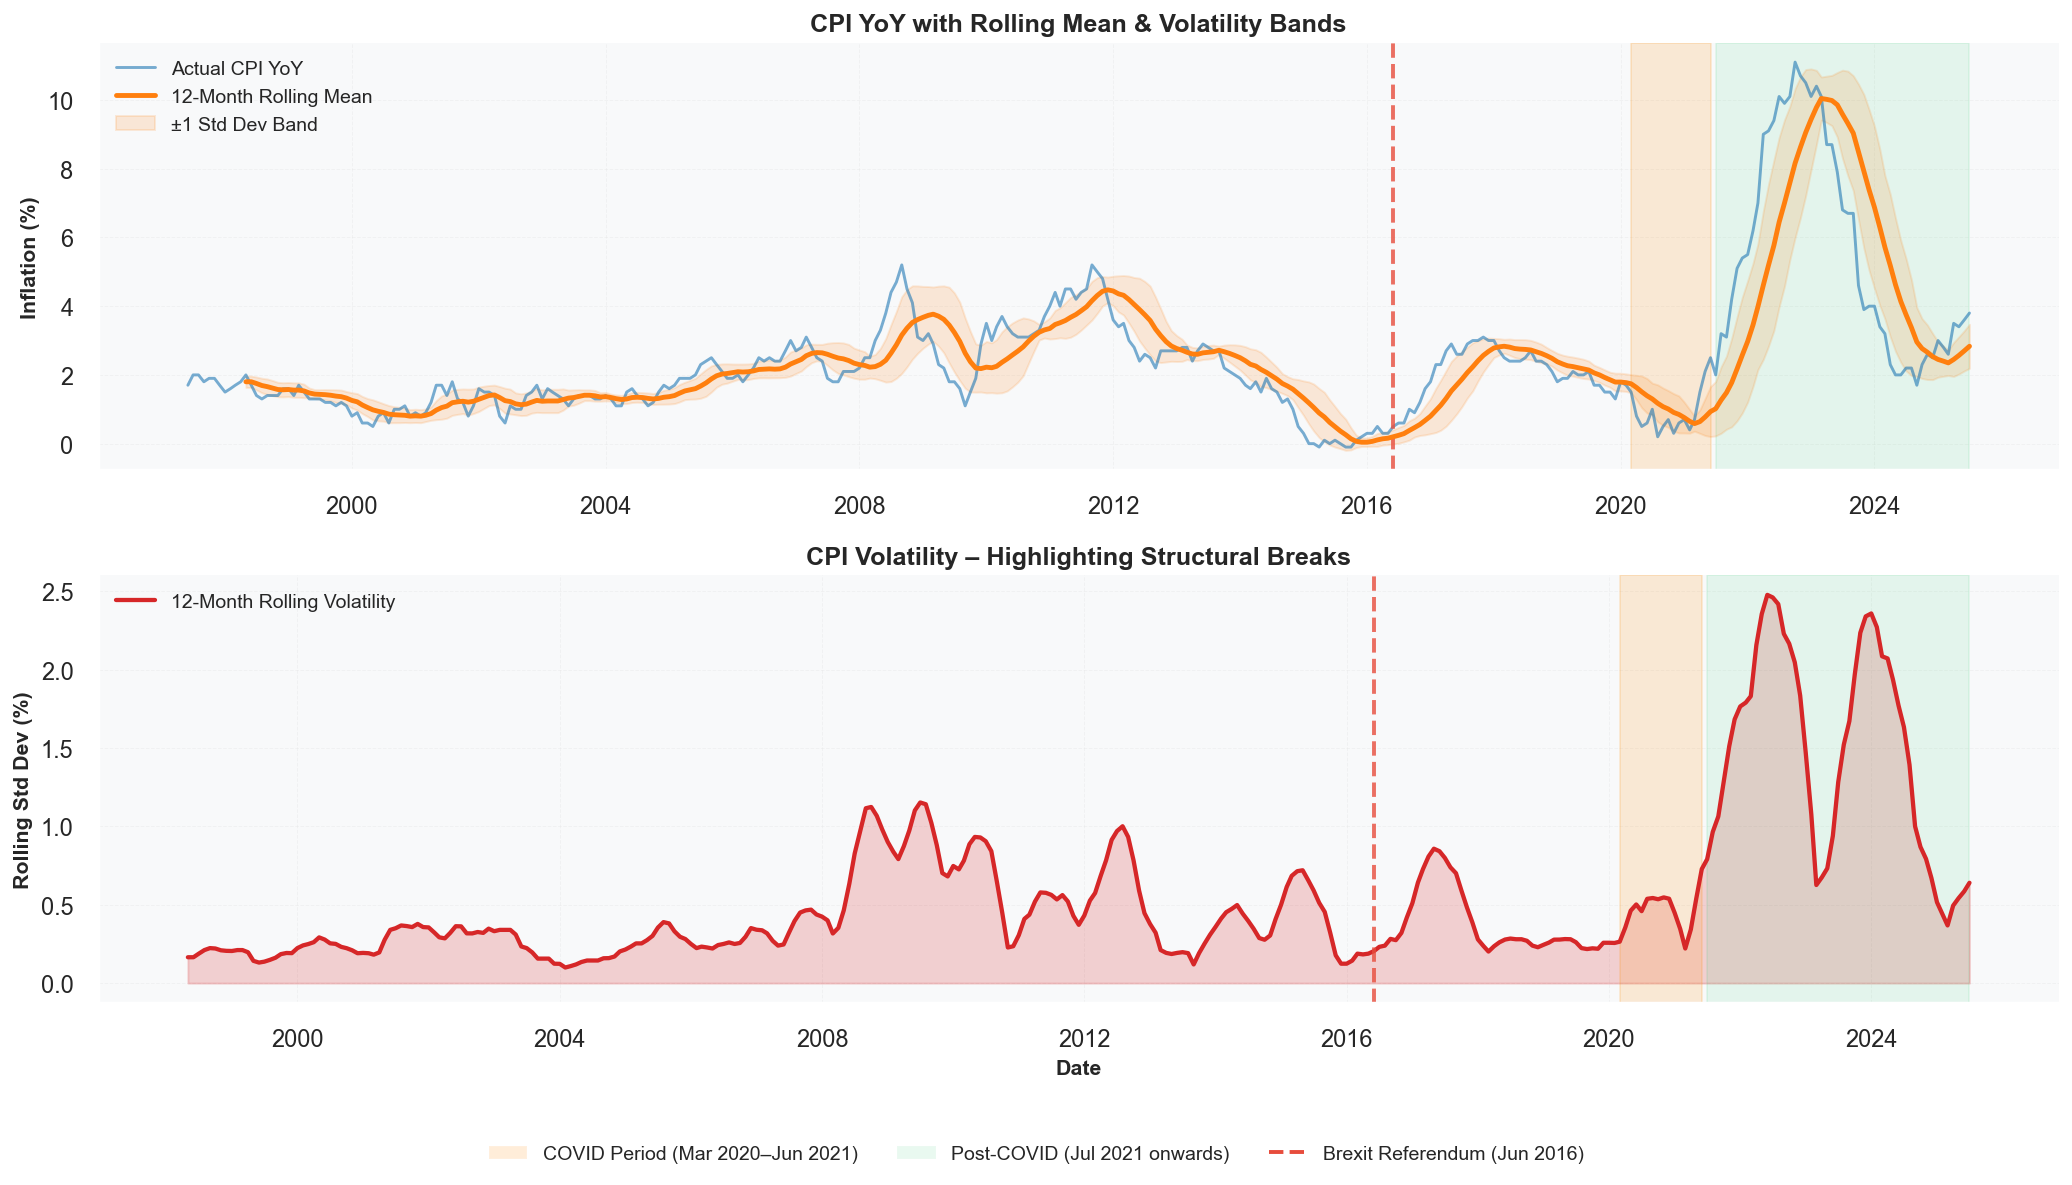

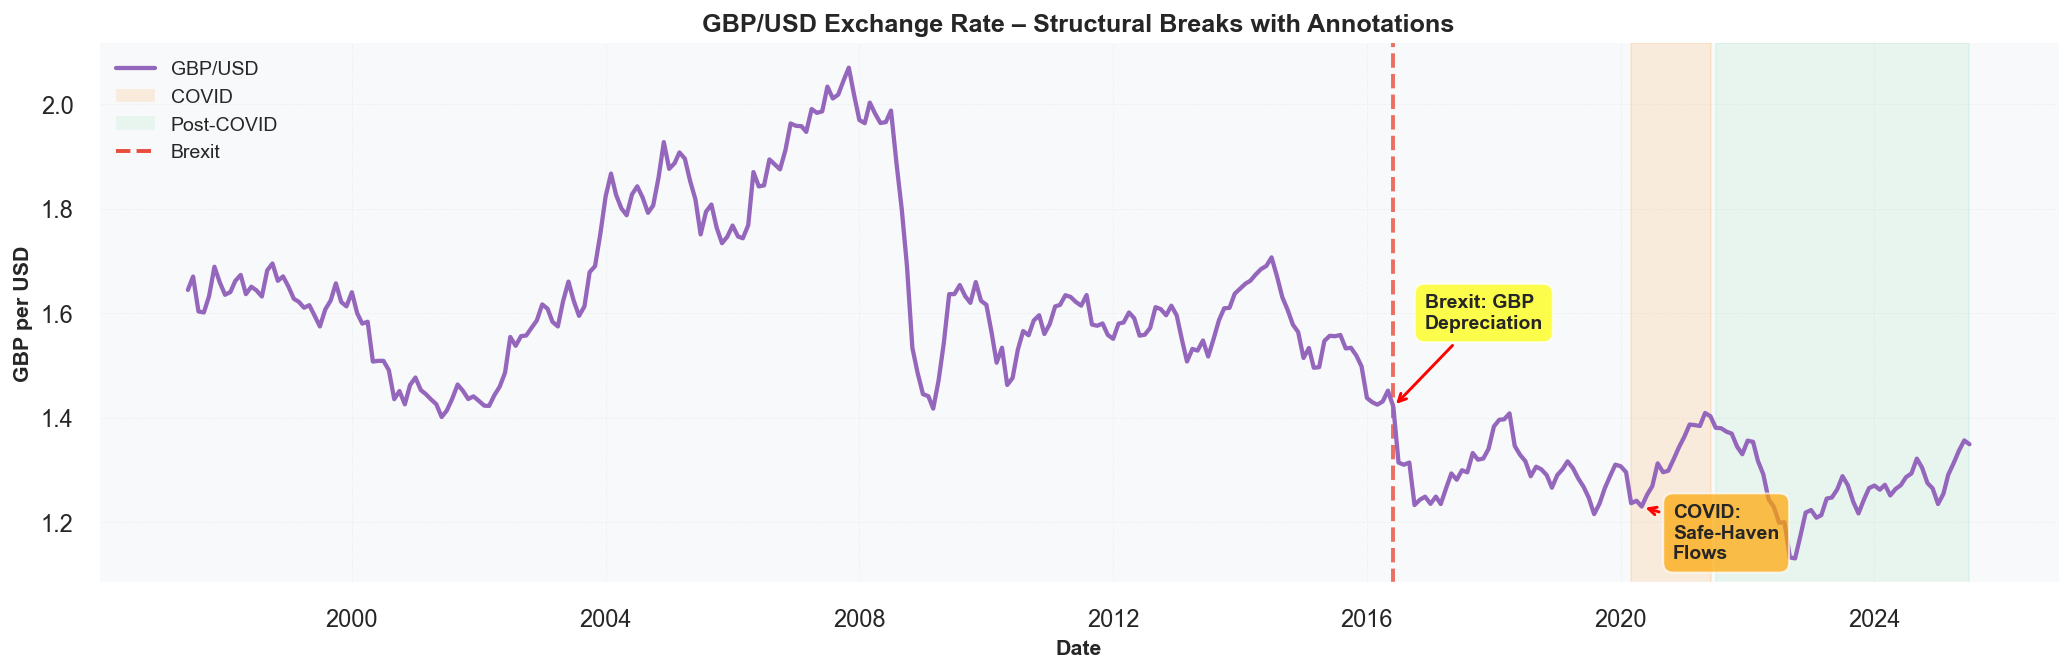

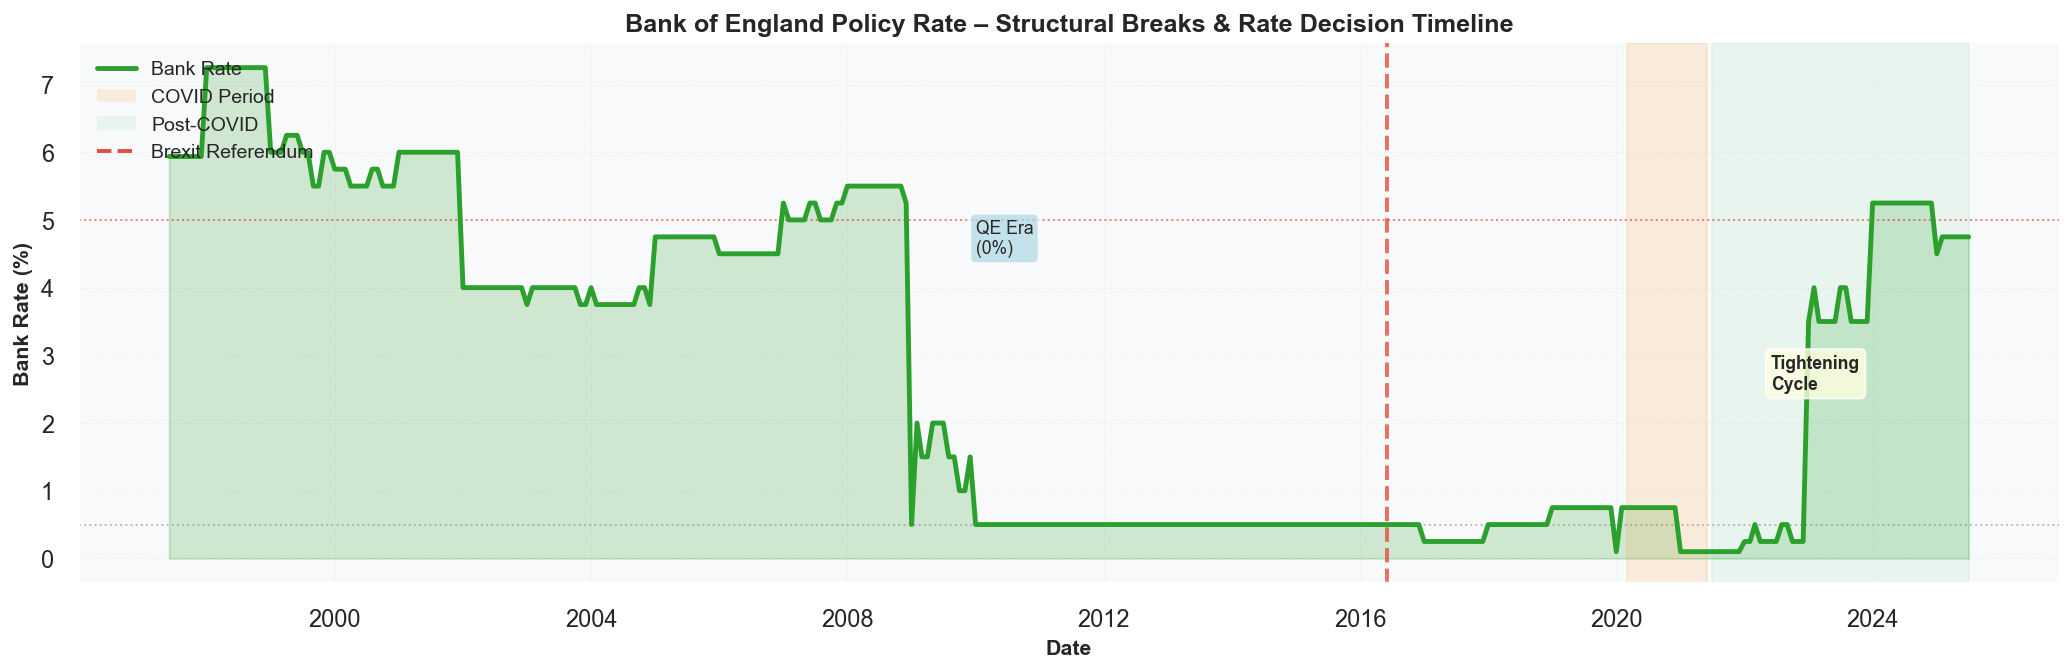

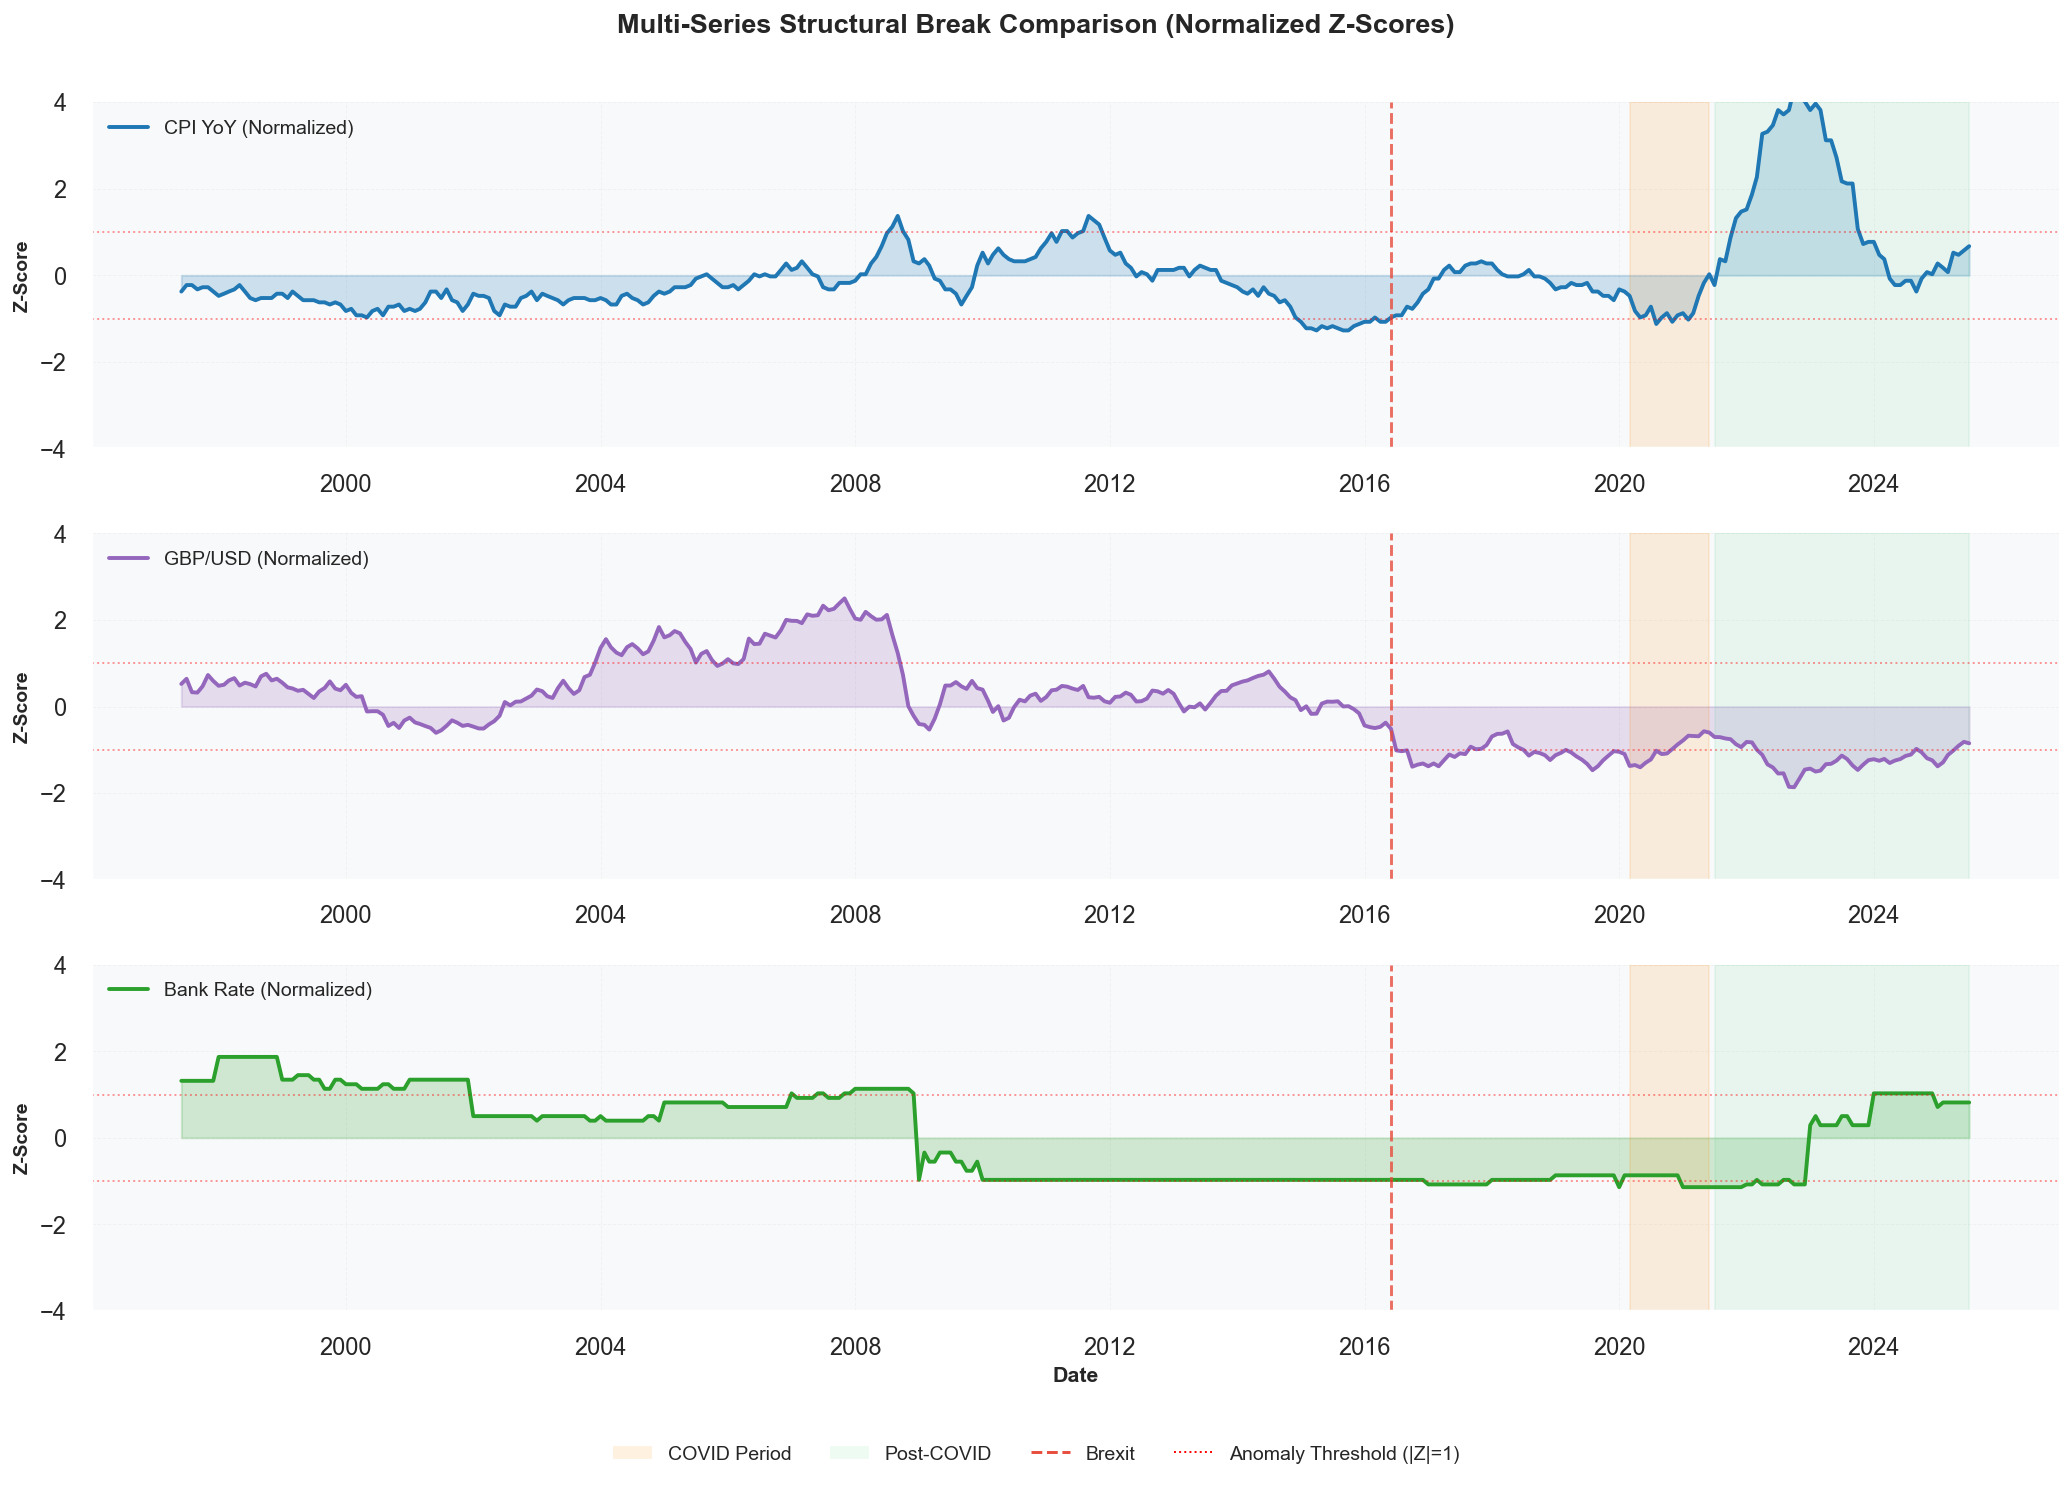


INTERPRETATION:

✅ Structural Breaks Identified:
  1. Brexit (Jun 2016): GBP weakens sharply → imports more expensive
  2. COVID (Mar 2020): Immediate shock to all variables; rate cut to near-zero
  3. Post-COVID (Jul 2021+): Inflation surge; aggressive rate hikes

📊 Key Insights:
  • CPI volatility peaked in 2021-2022 (energy crisis + supply shock)
  • FX shows structural break after Brexit (new 1.2-1.4 range vs pre-Brexit 1.6)
  • Bank Rate jumped from ~0% to 5%+ in fastest tightening cycle in decades

⚠️ Forecasting Implications:
  • Linear models (ARIMA) will fail due to regime changes
  • Use non-linear models (XGBoost, LSTM) or regime-switching models
  • Rolling validation essential (don't use pre-COVID data to forecast post-COVID)
  • Consider separate models for each regime or adaptive learning approaches



In [15]:
# Step 7 — Structural Break Analysis (Enhanced Visualization)

import matplotlib.dates as mdates
from matplotlib.patches import Patch, Rectangle
import matplotlib.patches as mpatches

infl_col = "CPI ANNUAL RATE 00: ALL ITEMS 2015=100"
fx_col   = "Exchange_USD"
bank_col = "Bank Rate"

# ----- Define regime boundaries -----
brexit_date       = pd.to_datetime("2016-06-01")
covid_start       = pd.to_datetime("2020-03-01")
covid_end         = pd.to_datetime("2021-06-01")
post_covid_start  = covid_end + pd.offsets.MonthBegin()

# ========================================================
# Custom function: Detect regime shifts using rolling stats
# ========================================================

def calculate_rolling_zscore(series, window=12):
    """Calculate rolling Z-score to detect anomalies."""
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    z_score = (series - rolling_mean) / rolling_std
    return z_score, rolling_mean, rolling_std

z_cpi, rm_cpi, rs_cpi = calculate_rolling_zscore(df[infl_col], window=12)

print("=" * 80)
print("STRUCTURAL BREAK DETECTION – ROLLING STATISTICS")
print("=" * 80)
print(f"\nCPI Series Statistics:")
print(f"  Mean: {df[infl_col].mean():.2f}%")
print(f"  Std Dev: {df[infl_col].std():.2f}%")
print(f"  Min: {df[infl_col].min():.2f}%")
print(f"  Max: {df[infl_col].max():.2f}%")
print(f"\n  High volatility periods (|Z-score| > 1.5):")

high_vol = df[np.abs(z_cpi) > 1.5][["Date", infl_col]]
if len(high_vol) > 0:
    for idx, row in high_vol.iterrows():
        print(f"    {row['Date'].strftime('%Y-%m')}: {row[infl_col]:.2f}% (Z-score: {z_cpi.iloc[idx]:.2f})")
else:
    print("    None detected in standard periods")

print("\n" + "=" * 80)


# ========================================================
# 7.1 CPI with Regime Highlighting & Rolling Mean
# ========================================================

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), dpi=140)

# Top panel: CPI with rolling mean
ax1.plot(df["Date"], df[infl_col], linewidth=1.5, color="#1F77B4", alpha=0.6, label="Actual CPI YoY")
ax1.plot(df["Date"], rm_cpi, linewidth=2.5, color="#FF7F0E", label="12-Month Rolling Mean", zorder=3)

# Highlight regimes
ax1.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.15)
ax1.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.10)
ax1.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

ax1.fill_between(df["Date"], rm_cpi - rs_cpi, rm_cpi + rs_cpi, 
                  color="#FF7F0E", alpha=0.15, label="±1 Std Dev Band")

ax1.set_title("CPI YoY with Rolling Mean & Volatility Bands", fontsize=13, fontweight="bold")
ax1.set_ylabel("Inflation (%)", fontsize=11, fontweight="bold")
ax1.grid(True, alpha=0.3, linestyle="--")
ax1.legend(loc="upper left", fontsize=10)

# Bottom panel: Rolling volatility (standard deviation)
ax2.plot(df["Date"], rs_cpi, linewidth=2.2, color="#D62728", label="12-Month Rolling Volatility")
ax2.fill_between(df["Date"], 0, rs_cpi, color="#D62728", alpha=0.2)

ax2.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.15)
ax2.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.10)
ax2.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

ax2.set_title("CPI Volatility – Highlighting Structural Breaks", fontsize=13, fontweight="bold")
ax2.set_xlabel("Date", fontsize=11, fontweight="bold")
ax2.set_ylabel("Rolling Std Dev (%)", fontsize=11, fontweight="bold")
ax2.grid(True, alpha=0.3, linestyle="--")
ax2.legend(loc="upper left", fontsize=10)

# Custom legend for both
handles = [
    mpatches.Patch(facecolor="#FF8C00", alpha=0.15, label="COVID Period (Mar 2020–Jun 2021)"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.10, label="Post-COVID (Jul 2021 onwards)"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit Referendum (Jun 2016)"),
]
fig.legend(handles=handles, loc="upper center", ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()


# ========================================================
# 7.2 FX (GBP/USD) Structural Breaks with Annotations
# ========================================================

fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[fx_col], linewidth=2.2, color="#9467BD", label="GBP/USD", zorder=3)

# Regime shading
ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8)

# Annotate Brexit impact
brexit_cpi_val = df[df["Date"] >= brexit_date][fx_col].iloc[0] if len(df[df["Date"] >= brexit_date]) > 0 else None
if brexit_cpi_val:
    ax.annotate("Brexit: GBP\nDepreciation",
                xy=(brexit_date, brexit_cpi_val),
                xytext=(brexit_date + pd.Timedelta(days=180), brexit_cpi_val + 0.15),
                fontsize=10, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.7),
                arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

# Annotate COVID impact
covid_peak = df[(df["Date"] >= covid_start) & (df["Date"] <= covid_end)][fx_col].min()
covid_date_min = df[(df["Date"] >= covid_start) & (df["Date"] <= covid_end)][fx_col].idxmin()
ax.annotate("COVID:\nSafe-Haven\nFlows",
            xy=(df.loc[covid_date_min, "Date"], covid_peak),
            xytext=(df.loc[covid_date_min, "Date"] + pd.Timedelta(days=180), covid_peak - 0.1),
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="orange", alpha=0.7),
            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))

ax.set_title("GBP/USD Exchange Rate – Structural Breaks with Annotations", fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("GBP per USD", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

handles = [
    plt.Line2D([], [], color="#9467BD", linewidth=2.2, label="GBP/USD"),
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit"),
]
ax.legend(handles=handles, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()


# ========================================================
# 7.3 Bank Rate Structural Breaks with Multi-Regime View
# ========================================================

fig, ax = plt.subplots(figsize=(15, 5), dpi=140)

ax.plot(df["Date"], df[bank_col], linewidth=2.5, color="#2CA02C", label="Bank Rate", zorder=3)
ax.fill_between(df["Date"], 0, df[bank_col], alpha=0.2, color="#2CA02C")

# Regime shading
ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=2, alpha=0.8, label="Brexit")

# Mark key rate decisions
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.axhline(5.0, color="red", linestyle=":", linewidth=1, alpha=0.5)

ax.set_title("Bank of England Policy Rate – Structural Breaks & Rate Decision Timeline", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.set_ylabel("Bank Rate (%)", fontsize=11, fontweight="bold")
ax.grid(True, alpha=0.3, linestyle="--")

# Annotate key periods
ax.text(pd.to_datetime("2010-01-01"), 4.5, "QE Era\n(0%)", fontsize=9, 
        bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.7))
ax.text(pd.to_datetime("2022-06-01"), 2.5, "Tightening\nCycle", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))

handles = [
    plt.Line2D([], [], color="#2CA02C", linewidth=2.5, label="Bank Rate"),
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID Period"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=2, label="Brexit Referendum"),
]
ax.legend(handles=handles, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()


# ========================================================
# 7.4 Multi-Series Structural Break Comparison
# ========================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 10), dpi=140)

# Normalize for comparison (z-score)
z_infl = (df[infl_col] - df[infl_col].mean()) / df[infl_col].std()
z_fx = (df[fx_col] - df[fx_col].mean()) / df[fx_col].std()
z_bank = (df[bank_col] - df[bank_col].mean()) / df[bank_col].std()

for idx, (ax, z_series, color, label) in enumerate([
    (axes[0], z_infl, "#1F77B4", "CPI YoY (Normalized)"),
    (axes[1], z_fx, "#9467BD", "GBP/USD (Normalized)"),
    (axes[2], z_bank, "#2CA02C", "Bank Rate (Normalized)")
]):
    ax.plot(df["Date"], z_series, linewidth=2, color=color, label=label)
    ax.fill_between(df["Date"], 0, z_series, alpha=0.2, color=color)
    
    # Regime shading
    ax.axvspan(covid_start, covid_end, color="#FF8C00", alpha=0.12)
    ax.axvspan(post_covid_start, df["Date"].max(), color="#2ECC71", alpha=0.08)
    ax.axvline(brexit_date, color="#E74C3C", linestyle="--", linewidth=1.5, alpha=0.8)
    
    # Confidence bands
    ax.axhline(1, color="red", linestyle=":", linewidth=1, alpha=0.4)
    ax.axhline(-1, color="red", linestyle=":", linewidth=1, alpha=0.4)
    
    ax.set_ylabel("Z-Score", fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(loc="upper left", fontsize=10)
    ax.set_ylim(-4, 4)

axes[2].set_xlabel("Date", fontsize=11, fontweight="bold")
fig.suptitle("Multi-Series Structural Break Comparison (Normalized Z-Scores)", 
             fontsize=14, fontweight="bold", y=1.00)

handles = [
    mpatches.Patch(facecolor="#FF8C00", alpha=0.12, label="COVID Period"),
    mpatches.Patch(facecolor="#2ECC71", alpha=0.08, label="Post-COVID"),
    plt.Line2D([], [], color="#E74C3C", linestyle="--", linewidth=1.5, label="Brexit"),
    plt.Line2D([], [], color="red", linestyle=":", linewidth=1, label="Anomaly Threshold (|Z|=1)"),
]
fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.show()


print("\n" + "=" * 80)
print("INTERPRETATION:")
print("=" * 80)
print("""
✅ Structural Breaks Identified:
  1. Brexit (Jun 2016): GBP weakens sharply → imports more expensive
  2. COVID (Mar 2020): Immediate shock to all variables; rate cut to near-zero
  3. Post-COVID (Jul 2021+): Inflation surge; aggressive rate hikes

📊 Key Insights:
  • CPI volatility peaked in 2021-2022 (energy crisis + supply shock)
  • FX shows structural break after Brexit (new 1.2-1.4 range vs pre-Brexit 1.6)
  • Bank Rate jumped from ~0% to 5%+ in fastest tightening cycle in decades
  
⚠️ Forecasting Implications:
  • Linear models (ARIMA) will fail due to regime changes
  • Use non-linear models (XGBoost, LSTM) or regime-switching models
  • Rolling validation essential (don't use pre-COVID data to forecast post-COVID)
  • Consider separate models for each regime or adaptive learning approaches
""")
print("=" * 80)